## The 2025 Agentic Ecosystem: MCP and A2A Protocols
### Course Exercise Collection for Lecture 1.5


This collection demonstrates:
1. Model Context Protocol (MCP) for tool/data interoperability
2. Agent-to-Agent (A2A) communication protocols
3. Multi-agent orchestration patterns
4. Service discovery and registration
5. Protocol standardization and compatibility

Each exercise includes both basic implementations and advanced patterns
for real-world agentic system development.

### Key Libraries Used
- asyncio: For handling asynchronous operations and concurrent agent communication
- dataclasses: For defining structured message and tool definition formats
- uuid: For generating unique identifiers for messages and agents
- typing: For type hints and better code documentation
- abc: For creating abstract base classes that define the protocol structure

In [1]:
"""
This collection demonstrates:
1. Model Context Protocol (MCP) for tool/data interoperability
2. Agent-to-Agent (A2A) communication protocols
3. Multi-agent orchestration patterns
4. Service discovery and registration
5. Protocol standardization and compatibility

Each exercise includes both basic implementations and advanced patterns
for real-world agentic system development.
"""

import asyncio
import json
import uuid
import time
from typing import Dict, List, Any, Optional, Callable, Union
from dataclasses import dataclass, asdict
from enum import Enum
from abc import ABC, abstractmethod
import hashlib
import threading
from queue import Queue, Empty
import logging

# Set up logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

### Short Description
This code implements a Model Context Protocol (MCP) framework for agent-to-agent communication and tool interoperability. It demonstrates how different AI agents can discover, register, and use each other's capabilities through standardized protocols, enabling complex multi-agent systems to work together seamlessly.



### Code Logic and Flow: High-Level Overview
The code establishes a standardized communication protocol (MCP) that allows different AI agents to discover each other's capabilities, request services, and exchange data. The system uses a message-based architecture where agents can register tools, handle incoming requests, and provide responses. The framework supports multiple provider types (like calculators and data access) that can be dynamically discovered and utilized by other agents in the system.

### Visual Flowchart
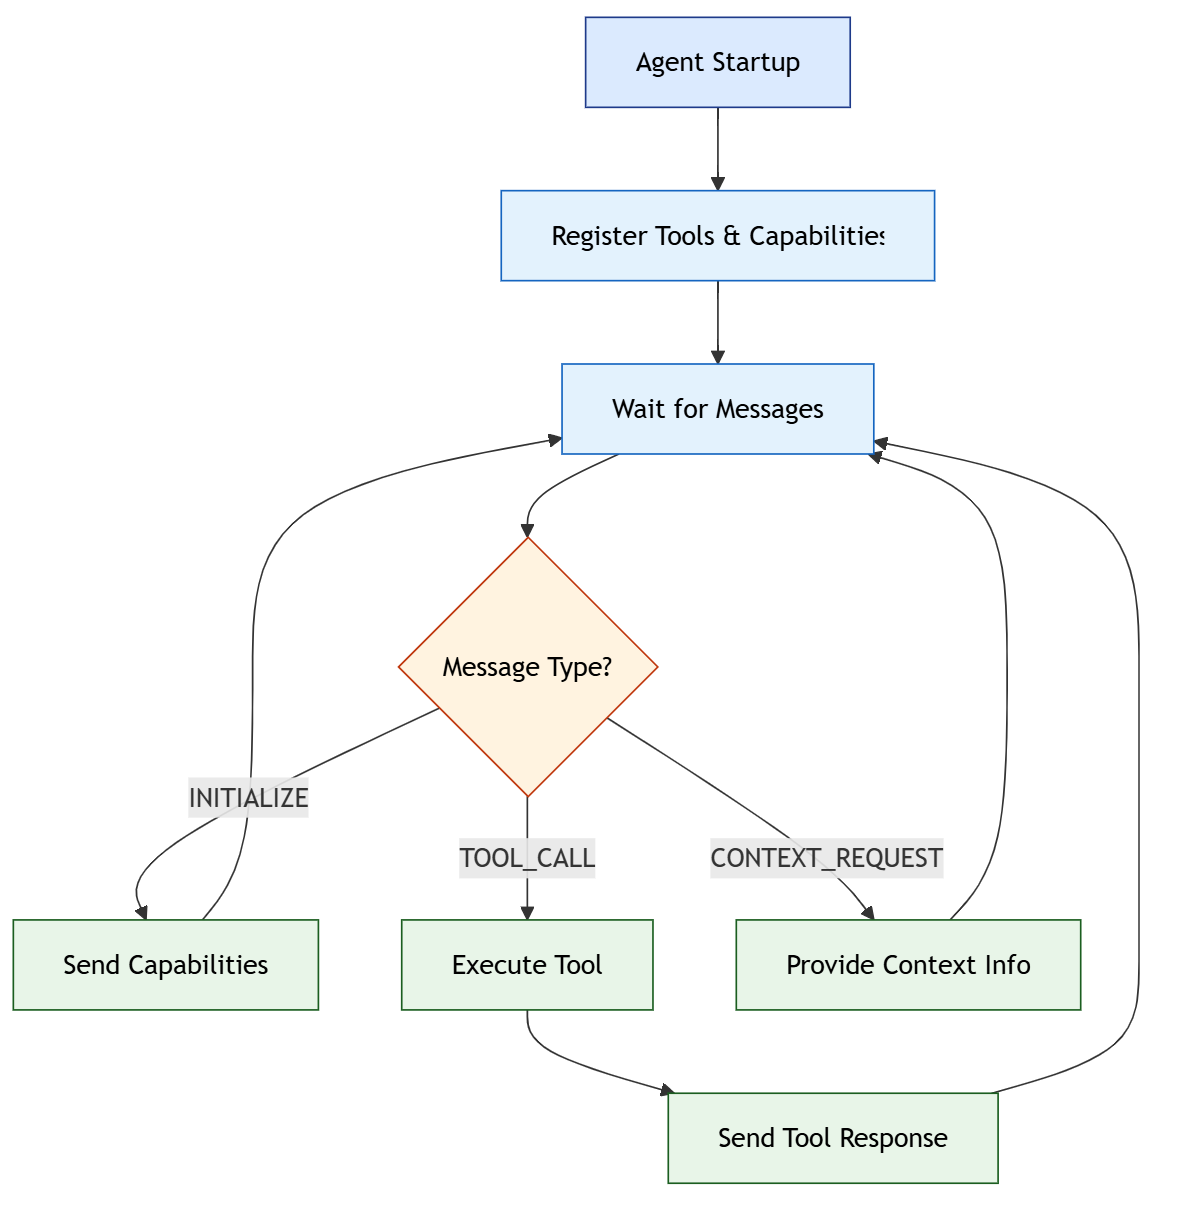

## Step-by-Step Code Breakdown
### Protocol Definition and Message Structure
- Defines standard message types for agent communication including initialization, tool calls, and context requests
- Creates a structured message format with sender/recipient IDs, timestamps, and correlation tracking
- Establishes tool definition schema with parameters, permissions, and return types

### MCP Provider Base Class
- Abstract base class that all service providers must implement
- Message routing system that automatically directs incoming messages to appropriate handlers
- Tool registration mechanism allowing providers to expose their capabilities
- Error handling with standardized error message formatting

### Calculator Service Provider Implementation
- Arithmetic operations including addition, subtraction, multiplication, and division
- Statistical functions for mean, median, standard deviation, and variance calculations
- Parameter validation to ensure correct input types and prevent errors like division by zero
- Async execution wrapper for CPU-bound mathematical operations

### Data Service Provider Implementation
- Data querying capabilities with filtering and pagination support
- Data transformation operations including sorting, field modification, and timestamp addition
- Mock data storage simulating real database interactions
- Permission-based access control for different data operations

### Message Processing Pipeline
- Message type detection and routing to appropriate handlers
- Correlation ID tracking for matching requests with responses
- Timestamp management for monitoring system performance and latency
- Payload validation to ensure message format compliance

### Connecting to the Lecture
- Protocol Standardization: Demonstrates how standardized protocols enable different AI systems to interoperate, directly connecting to lecture topics on interoperability frameworks
- Service Discovery: Shows practical implementation of dynamic capability discovery that was discussed theoretically in the agent orchestration lecture
- Error Propagation: The error handling mechanism illustrates how errors can be properly propagated through multi-agent systems without breaking entire workflows
- Latency Considerations: The async implementation and timestamp tracking connect to lecture discussions about managing latency in distributed AI systems
- Tool Composition: The ability to chain different tools from different providers demonstrates the composability concepts covered in the agentic patterns lecture
- Permission and Security: The required permissions in tool definitions implement the security models discussed for enterprise AI systems

In [2]:
# EXERCISE 1: MODEL CONTEXT PROTOCOL (MCP) IMPLEMENTATION

class MCPMessageType(Enum):
    """MCP Message Types following the protocol specification"""
    INITIALIZE = "initialize"
    INITIALIZED = "initialized"
    TOOL_CALL = "tool_call"
    TOOL_RESPONSE = "tool_response"
    CONTEXT_REQUEST = "context_request"
    CONTEXT_RESPONSE = "context_response"
    ERROR = "error"
    HEARTBEAT = "heartbeat"

@dataclass
class MCPMessage:
    """Standard MCP message format"""
    message_type: MCPMessageType
    message_id: str
    sender_id: str
    recipient_id: str
    timestamp: float
    payload: Dict[str, Any]
    correlation_id: Optional[str] = None

@dataclass
class ToolDefinition:
    """Tool definition following MCP specification"""
    name: str
    description: str
    parameters: Dict[str, Any]
    required_permissions: List[str]
    return_schema: Dict[str, Any]
    version: str = "1.0"

class MCPProvider(ABC):
    """Base class for MCP providers (tools, data sources, etc.)"""
    
    def __init__(self, provider_id: str, name: str):
        self.provider_id = provider_id
        self.name = name
        self.tools: Dict[str, ToolDefinition] = {}
        self.capabilities = set()
        self.message_handlers: Dict[MCPMessageType, Callable] = {
            MCPMessageType.INITIALIZE: self._handle_initialize,
            MCPMessageType.TOOL_CALL: self._handle_tool_call,
            MCPMessageType.CONTEXT_REQUEST: self._handle_context_request,
        }
    
    @abstractmethod
    async def execute_tool(self, tool_name: str, parameters: Dict[str, Any]) -> Any:
        """Execute a tool with given parameters"""
        pass
    
    def register_tool(self, tool: ToolDefinition, executor: Callable):
        """Register a tool with its executor function"""
        self.tools[tool.name] = tool
        setattr(self, f"_execute_{tool.name}", executor)
    
    async def process_message(self, message: MCPMessage) -> Optional[MCPMessage]:
        """Process incoming MCP message"""
        handler = self.message_handlers.get(message.message_type)
        if handler:
            return await handler(message)
        else:
            return self._create_error_message(
                message, f"Unsupported message type: {message.message_type}"
            )
    
    async def _handle_initialize(self, message: MCPMessage) -> MCPMessage:
        """Handle initialization request"""
        response_payload = {
            "provider_id": self.provider_id,
            "name": self.name,
            "version": "1.0",
            "capabilities": list(self.capabilities),
            "tools": {name: asdict(tool) for name, tool in self.tools.items()}
        }
        
        return MCPMessage(
            message_type=MCPMessageType.INITIALIZED,
            message_id=str(uuid.uuid4()),
            sender_id=self.provider_id,
            recipient_id=message.sender_id,
            timestamp=time.time(),
            payload=response_payload,
            correlation_id=message.message_id
        )
    
    async def _handle_tool_call(self, message: MCPMessage) -> MCPMessage:
        """Handle tool execution request"""
        tool_name = message.payload.get("tool_name")
        parameters = message.payload.get("parameters", {})
        
        if tool_name not in self.tools:
            return self._create_error_message(
                message, f"Unknown tool: {tool_name}"
            )
        
        try:
            result = await self.execute_tool(tool_name, parameters)
            response_payload = {
                "tool_name": tool_name,
                "result": result,
                "status": "success"
            }
        except Exception as e:
            response_payload = {
                "tool_name": tool_name,
                "error": str(e),
                "status": "error"
            }
        
        return MCPMessage(
            message_type=MCPMessageType.TOOL_RESPONSE,
            message_id=str(uuid.uuid4()),
            sender_id=self.provider_id,
            recipient_id=message.sender_id,
            timestamp=time.time(),
            payload=response_payload,
            correlation_id=message.message_id
        )
    
    async def _handle_context_request(self, message: MCPMessage) -> MCPMessage:
        """Handle context information request"""
        context_type = message.payload.get("context_type")
        
        context_data = {}
        if context_type == "capabilities":
            context_data = {"capabilities": list(self.capabilities)}
        elif context_type == "tools":
            context_data = {"tools": list(self.tools.keys())}
        elif context_type == "status":
            context_data = {"status": "active", "load": 0.1}
        
        return MCPMessage(
            message_type=MCPMessageType.CONTEXT_RESPONSE,
            message_id=str(uuid.uuid4()),
            sender_id=self.provider_id,
            recipient_id=message.sender_id,
            timestamp=time.time(),
            payload=context_data,
            correlation_id=message.message_id
        )
    
    def _create_error_message(self, original_message: MCPMessage, error_msg: str) -> MCPMessage:
        """Create an error response message"""
        return MCPMessage(
            message_type=MCPMessageType.ERROR,
            message_id=str(uuid.uuid4()),
            sender_id=self.provider_id,
            recipient_id=original_message.sender_id,
            timestamp=time.time(),
            payload={"error": error_msg},
            correlation_id=original_message.message_id
        )

# Example MCP Providers

class CalculatorMCPProvider(MCPProvider):
    """Example MCP provider offering calculator tools"""
    
    def __init__(self):
        super().__init__("calc_provider_001", "Calculator Service")
        self.capabilities.add("mathematical_operations")
        
        # Register calculator tools
        self._register_calculator_tools()
    
    def _register_calculator_tools(self):
        """Register all calculator tools"""
        # Basic arithmetic tool
        arithmetic_tool = ToolDefinition(
            name="arithmetic",
            description="Perform basic arithmetic operations",
            parameters={
                "type": "object",
                "properties": {
                    "operation": {"type": "string", "enum": ["add", "subtract", "multiply", "divide"]},
                    "operands": {"type": "array", "items": {"type": "number"}}
                },
                "required": ["operation", "operands"]
            },
            required_permissions=["execute"],
            return_schema={"type": "number"}
        )
        self.register_tool(arithmetic_tool, self._execute_arithmetic)
        
        # Statistical operations tool
        stats_tool = ToolDefinition(
            name="statistics",
            description="Calculate statistical measures",
            parameters={
                "type": "object",
                "properties": {
                    "operation": {"type": "string", "enum": ["mean", "median", "std", "variance"]},
                    "data": {"type": "array", "items": {"type": "number"}}
                },
                "required": ["operation", "data"]
            },
            required_permissions=["execute"],
            return_schema={"type": "number"}
        )
        self.register_tool(stats_tool, self._execute_statistics)
    
    async def execute_tool(self, tool_name: str, parameters: Dict[str, Any]) -> Any:
        """Execute tool by name"""
        executor = getattr(self, f"_execute_{tool_name}", None)
        if executor:
            return await asyncio.get_event_loop().run_in_executor(None, executor, parameters)
        else:
            raise ValueError(f"No executor found for tool: {tool_name}")
    
    def _execute_arithmetic(self, parameters: Dict[str, Any]) -> float:
        """Execute arithmetic operations"""
        operation = parameters["operation"]
        operands = parameters["operands"]
        
        if operation == "add":
            return sum(operands)
        elif operation == "subtract":
            return operands[0] - sum(operands[1:])
        elif operation == "multiply":
            result = 1
            for op in operands:
                result *= op
            return result
        elif operation == "divide":
            result = operands[0]
            for op in operands[1:]:
                if op == 0:
                    raise ValueError("Division by zero")
                result /= op
            return result
    
    def _execute_statistics(self, parameters: Dict[str, Any]) -> float:
        """Execute statistical operations"""
        import statistics
        
        operation = parameters["operation"]
        data = parameters["data"]
        
        if not data:
            raise ValueError("Data cannot be empty")
        
        if operation == "mean":
            return statistics.mean(data)
        elif operation == "median":
            return statistics.median(data)
        elif operation == "std":
            return statistics.stdev(data) if len(data) > 1 else 0
        elif operation == "variance":
            return statistics.variance(data) if len(data) > 1 else 0

class DataMCPProvider(MCPProvider):
    """Example MCP provider offering data access tools"""
    
    def __init__(self):
        super().__init__("data_provider_001", "Data Access Service")
        self.capabilities.add("data_access")
        self.capabilities.add("data_transformation")
        
        # Mock data storage
        self.data_store = {
            "users": [
                {"id": 1, "name": "Alice", "email": "alice@example.com"},
                {"id": 2, "name": "Bob", "email": "bob@example.com"}
            ],
            "products": [
                {"id": 1, "name": "Widget A", "price": 19.99},
                {"id": 2, "name": "Widget B", "price": 29.99}
            ]
        }
        
        self._register_data_tools()
    
    def _register_data_tools(self):
        """Register data access tools"""
        query_tool = ToolDefinition(
            name="query_data",
            description="Query data from available datasets",
            parameters={
                "type": "object",
                "properties": {
                    "dataset": {"type": "string"},
                    "filters": {"type": "object"},
                    "limit": {"type": "integer", "default": 10}
                },
                "required": ["dataset"]
            },
            required_permissions=["read"],
            return_schema={"type": "array"}
        )
        self.register_tool(query_tool, self._execute_query_data)
        
        transform_tool = ToolDefinition(
            name="transform_data",
            description="Transform data using specified operations",
            parameters={
                "type": "object",
                "properties": {
                    "data": {"type": "array"},
                    "operations": {"type": "array", "items": {"type": "string"}}
                },
                "required": ["data", "operations"]
            },
            required_permissions=["read", "transform"],
            return_schema={"type": "array"}
        )
        self.register_tool(transform_tool, self._execute_transform_data)
    
    async def execute_tool(self, tool_name: str, parameters: Dict[str, Any]) -> Any:
        """Execute tool by name"""
        executor = getattr(self, f"_execute_{tool_name}", None)
        if executor:
            return await asyncio.get_event_loop().run_in_executor(None, executor, parameters)
        else:
            raise ValueError(f"No executor found for tool: {tool_name}")
    
    def _execute_query_data(self, parameters: Dict[str, Any]) -> List[Dict[str, Any]]:
        """Execute data query"""
        dataset = parameters["dataset"]
        filters = parameters.get("filters", {})
        limit = parameters.get("limit", 10)
        
        if dataset not in self.data_store:
            raise ValueError(f"Dataset not found: {dataset}")
        
        data = self.data_store[dataset]
        
        # Apply filters
        filtered_data = data
        for key, value in filters.items():
            filtered_data = [item for item in filtered_data if item.get(key) == value]
        
        # Apply limit
        return filtered_data[:limit]
    
    def _execute_transform_data(self, parameters: Dict[str, Any]) -> List[Dict[str, Any]]:
        """Execute data transformation"""
        data = parameters["data"]
        operations = parameters["operations"]
        
        result = data.copy()
        
        for operation in operations:
            if operation == "sort_by_name":
                result = sorted(result, key=lambda x: x.get("name", ""))
            elif operation == "add_timestamp":
                for item in result:
                    item["timestamp"] = time.time()
            elif operation == "uppercase_names":
                for item in result:
                    if "name" in item:
                        item["name"] = item["name"].upper()
        
        return result


### Short Description
This code implements a comprehensive Agent-to-Agent (A2A) communication system that enables multiple AI agents to discover, communicate, and collaborate. It demonstrates how autonomous agents can exchange messages, delegate tasks, and work together through a centralized communication bus using standardized protocols for complex multi-agent workflows.

### Code Logic and Flow: High-Level Overview
The system establishes a centralized communication bus that routes messages between registered agents. Each agent can register specific capabilities, send various types of messages (direct, broadcast, delegation), and handle incoming requests. The architecture supports complex interactions including handshakes, capability requests, task delegation, and collaborative workflows, with proper error handling and response tracking.

### Visual Flowchart
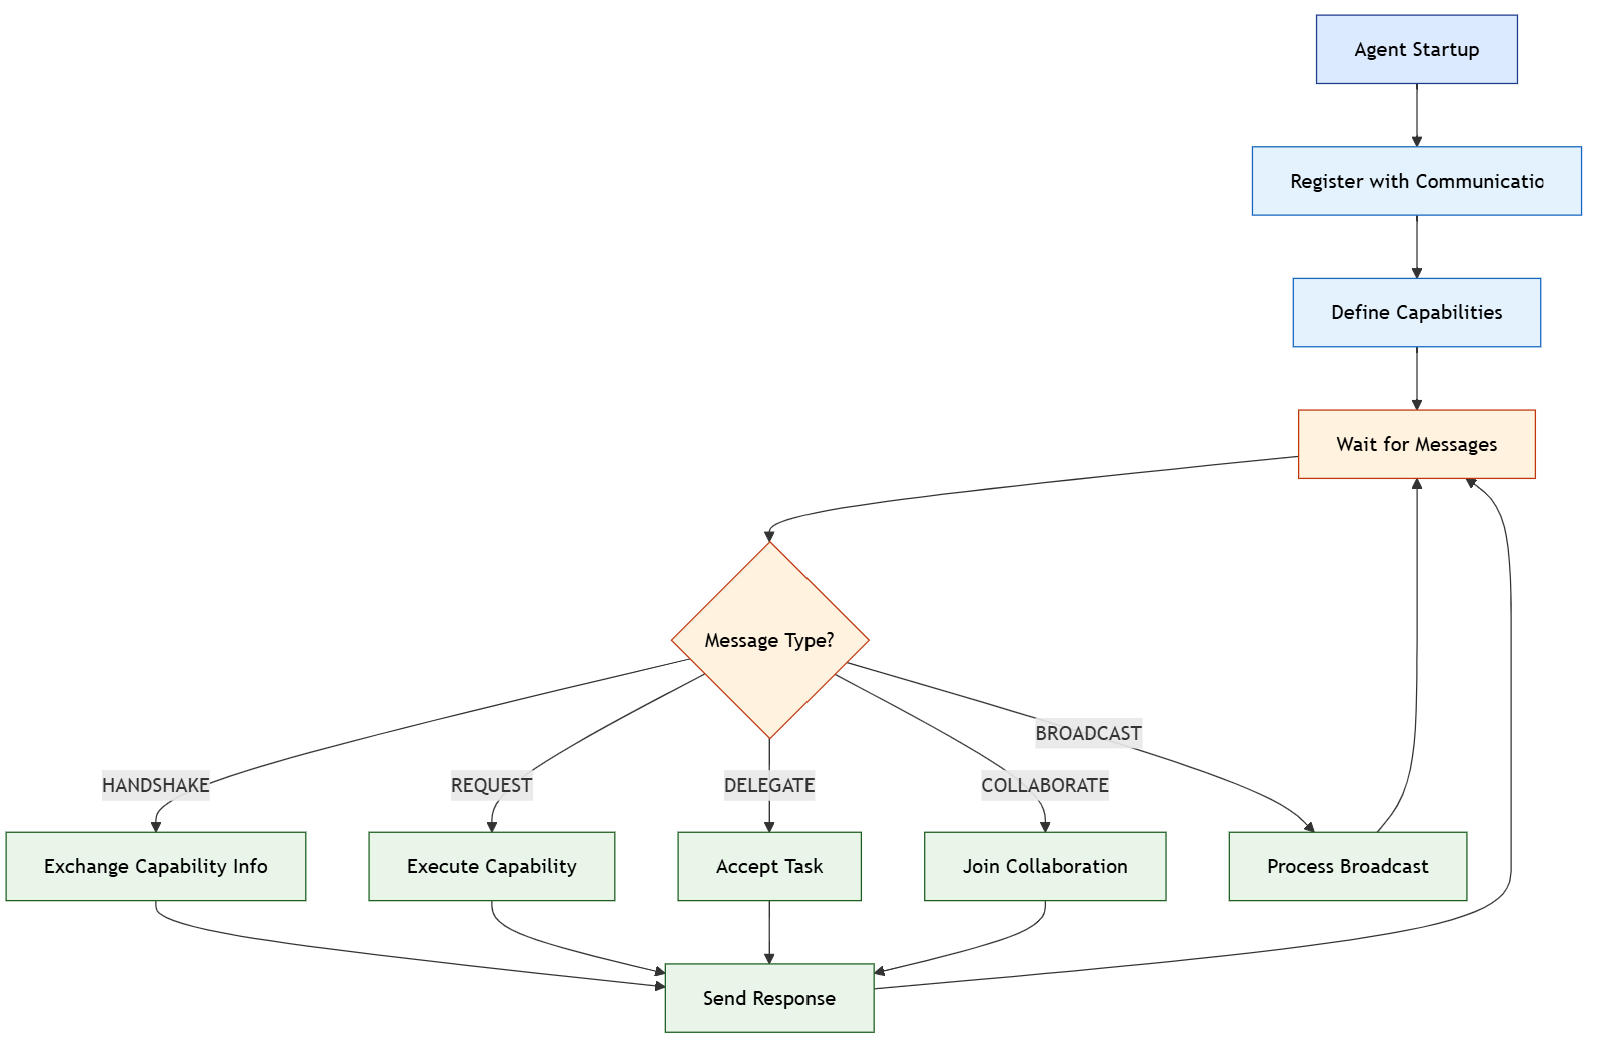

## Step-by-Step Code Breakdown
### Communication Protocol Definition
- Message Type Enumeration defines eight different communication patterns for various agent interactions
- Structured Message Format includes sender/recipient IDs, timestamps, priorities, and correlation tracking
- Capability Definition Schema standardizes how agents describe their skills and requirements

### Central Communication Bus
- Agent Registration System maintains a registry of all active agents in the ecosystem
- Message Queue Management handles concurrent message delivery with proper sequencing
- Message Routing Logic directs messages to specific recipients or broadcasts to multiple agents
- Thread-based Processing ensures non-blocking message handling across the system

### Base Agent Node Implementation
- Capability Management allows agents to register and expose their specialized skills
- Message Handler Registry maps incoming message types to appropriate processing functions
- Inbox System queues incoming messages for orderly processing
- Conversation Tracking maintains state for ongoing multi-agent collaborations

### Message Handling System
- Handshake Protocol enables agents to discover each other's capabilities upon connection
- Capability Request Processing executes registered functions based on incoming requests
- Delegation Handling allows agents to accept and manage tasks from other agents
- Collaboration Management supports multi-agent teamwork on complex problems
- Broadcast Processing handles system-wide announcements and notifications

### Specialized Agent Implementations
- Calculator Agent provides mathematical operations including addition, multiplication, and power functions
- Data Analysis Agent offers statistical analysis capabilities for dataset summarization and distribution analysis
- Orchestrator Agent coordinates multi-step workflows and manages complex agent collaborations

### Response Management
- Success Response Formatting standardizes positive results with consistent data structure
- Error Response Handling provides meaningful error messages back to requesting agents
- Correlation ID Tracking ensures responses are properly matched with their original requests

### Connecting to the Lecture
- Communication Patterns: Implements the direct, broadcast, and delegation patterns discussed in the multi-agent communication lecture
- Capability Discovery: Demonstrates practical implementation of the service discovery mechanisms covered in agent coordination theory
- Message Prioritization: The priority system connects to lecture topics about quality of service in distributed AI systems
- Error Propagation: Shows how errors are properly communicated back through the system without crashing entire workflows
- Resource Management: The cost field in capabilities implements the resource accounting concepts discussed for scalable agent systems
- Workflow Orchestration: The orchestrator agent demonstrates the choreography patterns covered in multi-agent system design
- Conversation State Management: The active conversations tracking connects to lecture topics about maintaining context in extended agent interactions

In [3]:
# EXERCISE 2: AGENT-TO-AGENT (A2A) COMMUNICATION PROTOCOL

class A2AMessageType(Enum):
    """A2A Message Types for inter-agent communication"""
    HANDSHAKE = "handshake"
    REQUEST = "request"
    RESPONSE = "response"
    BROADCAST = "broadcast"
    DELEGATE = "delegate"
    COLLABORATE = "collaborate"
    STATUS_UPDATE = "status_update"
    TERMINATION = "termination"

@dataclass
class A2AMessage:
    """A2A message format for inter-agent communication"""
    message_type: A2AMessageType
    message_id: str
    sender_agent_id: str
    recipient_agent_id: Optional[str]  # None for broadcasts
    timestamp: float
    payload: Dict[str, Any]
    priority: int = 1  # 1=low, 5=high
    requires_response: bool = False
    correlation_id: Optional[str] = None

@dataclass
class AgentCapability:
    """Agent capability definition"""
    name: str
    description: str
    input_schema: Dict[str, Any]
    output_schema: Dict[str, Any]
    cost: float = 0.0  # Resource cost

class A2ACommunicationBus:
    """Central communication bus for A2A messaging"""
    
    def __init__(self):
        self.registered_agents: Dict[str, 'AgentNode'] = {}
        self.message_queue = Queue()
        self.message_history: List[A2AMessage] = []
        self.running = False
        self.bus_thread = None
    
    def register_agent(self, agent: 'AgentNode'):
        """Register an agent with the communication bus"""
        self.registered_agents[agent.agent_id] = agent
        logger.info(f"Agent {agent.agent_id} registered with communication bus")
    
    def unregister_agent(self, agent_id: str):
        """Unregister an agent from the communication bus"""
        if agent_id in self.registered_agents:
            del self.registered_agents[agent_id]
            logger.info(f"Agent {agent_id} unregistered from communication bus")
    
    def send_message(self, message: A2AMessage):
        """Send message through the communication bus"""
        self.message_queue.put(message)
        self.message_history.append(message)
        logger.info(f"Message {message.message_id} queued from {message.sender_agent_id}")
    
    def start(self):
        """Start the communication bus message processing"""
        self.running = True
        self.bus_thread = threading.Thread(target=self._process_messages)
        self.bus_thread.start()
        logger.info("A2A Communication bus started")
    
    def stop(self):
        """Stop the communication bus"""
        self.running = False
        if self.bus_thread:
            self.bus_thread.join()
        logger.info("A2A Communication bus stopped")
    
    def _process_messages(self):
        """Process messages in the queue"""
        while self.running:
            try:
                message = self.message_queue.get(timeout=1)
                self._route_message(message)
            except Empty:
                continue
    
    def _route_message(self, message: A2AMessage):
        """Route message to appropriate recipient(s)"""
        if message.recipient_agent_id:
            # Direct message
            if message.recipient_agent_id in self.registered_agents:
                recipient = self.registered_agents[message.recipient_agent_id]
                recipient.receive_message(message)
            else:
                logger.warning(f"Recipient {message.recipient_agent_id} not found")
        else:
            # Broadcast message
            for agent_id, agent in self.registered_agents.items():
                if agent_id != message.sender_agent_id:
                    agent.receive_message(message)

class AgentNode:
    """Base class for agents in the A2A ecosystem"""
    
    def __init__(self, agent_id: str, name: str, agent_type: str):
        self.agent_id = agent_id
        self.name = name
        self.agent_type = agent_type
        self.capabilities: Dict[str, AgentCapability] = {}
        self.status = "idle"
        self.communication_bus: Optional[A2ACommunicationBus] = None
        self.message_handlers: Dict[A2AMessageType, Callable] = {
            A2AMessageType.HANDSHAKE: self._handle_handshake,
            A2AMessageType.REQUEST: self._handle_request,
            A2AMessageType.DELEGATE: self._handle_delegate,
            A2AMessageType.COLLABORATE: self._handle_collaborate,
            A2AMessageType.BROADCAST: self._handle_broadcast,
        }
        self.inbox = Queue()
        self.active_conversations: Dict[str, Dict] = {}
    
    def connect_to_bus(self, bus: A2ACommunicationBus):
        """Connect agent to communication bus"""
        self.communication_bus = bus
        bus.register_agent(self)
    
    def add_capability(self, capability: AgentCapability, executor: Callable):
        """Add a capability to this agent"""
        self.capabilities[capability.name] = capability
        setattr(self, f"_execute_{capability.name}", executor)
    
    def send_message(self, message: A2AMessage):
        """Send message through the communication bus"""
        if self.communication_bus:
            self.communication_bus.send_message(message)
        else:
            logger.error(f"Agent {self.agent_id} not connected to communication bus")
    
    def receive_message(self, message: A2AMessage):
        """Receive message from communication bus"""
        self.inbox.put(message)
        self._process_message(message)
    
    def _process_message(self, message: A2AMessage):
        """Process incoming message"""
        handler = self.message_handlers.get(message.message_type)
        if handler:
            try:
                handler(message)
            except Exception as e:
                logger.error(f"Error processing message {message.message_id}: {e}")
        else:
            logger.warning(f"No handler for message type {message.message_type}")
    
    def _handle_handshake(self, message: A2AMessage):
        """Handle handshake request"""
        logger.info(f"Agent {self.agent_id} received handshake from {message.sender_agent_id}")
        
        response = A2AMessage(
            message_type=A2AMessageType.RESPONSE,
            message_id=str(uuid.uuid4()),
            sender_agent_id=self.agent_id,
            recipient_agent_id=message.sender_agent_id,
            timestamp=time.time(),
            payload={
                "status": "acknowledged",
                "capabilities": {name: asdict(cap) for name, cap in self.capabilities.items()},
                "agent_type": self.agent_type
            },
            correlation_id=message.message_id
        )
        
        self.send_message(response)
    
    def _handle_request(self, message: A2AMessage):
        """Handle capability request"""
        capability_name = message.payload.get("capability")
        parameters = message.payload.get("parameters", {})
        
        if capability_name not in self.capabilities:
            self._send_error_response(message, f"Capability {capability_name} not available")
            return
        
        try:
            # Execute capability
            executor = getattr(self, f"_execute_{capability_name}", None)
            if executor:
                result = executor(parameters)
                self._send_success_response(message, result)
            else:
                self._send_error_response(message, f"No executor for {capability_name}")
        except Exception as e:
            self._send_error_response(message, str(e))
    
    def _handle_delegate(self, message: A2AMessage):
        """Handle delegation request"""
        task = message.payload.get("task")
        logger.info(f"Agent {self.agent_id} received delegation: {task}")
        
        # Simple delegation handling
        response = A2AMessage(
            message_type=A2AMessageType.RESPONSE,
            message_id=str(uuid.uuid4()),
            sender_agent_id=self.agent_id,
            recipient_agent_id=message.sender_agent_id,
            timestamp=time.time(),
            payload={"status": "accepted", "task_id": str(uuid.uuid4())},
            correlation_id=message.message_id
        )
        
        self.send_message(response)
    
    def _handle_collaborate(self, message: A2AMessage):
        """Handle collaboration request"""
        collaboration_id = message.payload.get("collaboration_id")
        task_description = message.payload.get("task_description")
        
        logger.info(f"Agent {self.agent_id} invited to collaborate on: {task_description}")
        
        # Join collaboration
        self.active_conversations[collaboration_id] = {
            "type": "collaboration",
            "participants": [message.sender_agent_id],
            "task": task_description,
            "status": "active"
        }
        
        response = A2AMessage(
            message_type=A2AMessageType.RESPONSE,
            message_id=str(uuid.uuid4()),
            sender_agent_id=self.agent_id,
            recipient_agent_id=message.sender_agent_id,
            timestamp=time.time(),
            payload={"status": "joined", "collaboration_id": collaboration_id},
            correlation_id=message.message_id
        )
        
        self.send_message(response)
    
    def _handle_broadcast(self, message: A2AMessage):
        """Handle broadcast message"""
        broadcast_type = message.payload.get("type")
        logger.info(f"Agent {self.agent_id} received broadcast: {broadcast_type}")
    
    def _send_success_response(self, original_message: A2AMessage, result: Any):
        """Send successful response"""
        response = A2AMessage(
            message_type=A2AMessageType.RESPONSE,
            message_id=str(uuid.uuid4()),
            sender_agent_id=self.agent_id,
            recipient_agent_id=original_message.sender_agent_id,
            timestamp=time.time(),
            payload={"status": "success", "result": result},
            correlation_id=original_message.message_id
        )
        self.send_message(response)
    
    def _send_error_response(self, original_message: A2AMessage, error_msg: str):
        """Send error response"""
        response = A2AMessage(
            message_type=A2AMessageType.RESPONSE,
            message_id=str(uuid.uuid4()),
            sender_agent_id=self.agent_id,
            recipient_agent_id=original_message.sender_agent_id,
            timestamp=time.time(),
            payload={"status": "error", "error": error_msg},
            correlation_id=original_message.message_id
        )
        self.send_message(response)

# Example Agent Implementations

class CalculatorAgent(AgentNode):
    """Agent specialized in mathematical calculations"""
    
    def __init__(self, agent_id: str):
        super().__init__(agent_id, "Calculator Agent", "computational")
        self._setup_capabilities()
    
    def _setup_capabilities(self):
        """Setup calculator capabilities"""
        math_capability = AgentCapability(
            name="mathematical_operations",
            description="Perform various mathematical operations",
            input_schema={
                "type": "object",
                "properties": {
                    "operation": {"type": "string"},
                    "operands": {"type": "array"}
                }
            },
            output_schema={"type": "number"},
            cost=0.1
        )
        
        self.add_capability(math_capability, self._execute_mathematical_operations)
    
    def _execute_mathematical_operations(self, parameters: Dict[str, Any]) -> float:
        """Execute mathematical operations"""
        operation = parameters.get("operation")
        operands = parameters.get("operands", [])
        
        if operation == "add":
            return sum(operands)
        elif operation == "multiply":
            result = 1
            for op in operands:
                result *= op
            return result
        elif operation == "power":
            return operands[0] ** operands[1] if len(operands) >= 2 else 0
        else:
            raise ValueError(f"Unsupported operation: {operation}")

class DataAnalysisAgent(AgentNode):
    """Agent specialized in data analysis"""
    
    def __init__(self, agent_id: str):
        super().__init__(agent_id, "Data Analysis Agent", "analytical")
        self._setup_capabilities()
    
    def _setup_capabilities(self):
        """Setup data analysis capabilities"""
        analysis_capability = AgentCapability(
            name="data_analysis",
            description="Analyze datasets and provide insights",
            input_schema={
                "type": "object",
                "properties": {
                    "data": {"type": "array"},
                    "analysis_type": {"type": "string"}
                }
            },
            output_schema={"type": "object"},
            cost=0.5
        )
        
        self.add_capability(analysis_capability, self._execute_data_analysis)
    
    def _execute_data_analysis(self, parameters: Dict[str, Any]) -> Dict[str, Any]:
        """Execute data analysis"""
        data = parameters.get("data", [])
        analysis_type = parameters.get("analysis_type", "summary")
        
        if not data:
            return {"error": "No data provided"}
        
        numeric_data = [x for x in data if isinstance(x, (int, float))]
        
        if analysis_type == "summary":
            return {
                "count": len(data),
                "numeric_count": len(numeric_data),
                "mean": sum(numeric_data) / len(numeric_data) if numeric_data else 0,
                "min": min(numeric_data) if numeric_data else None,
                "max": max(numeric_data) if numeric_data else None
            }
        elif analysis_type == "distribution":
            # Simple distribution analysis
            return {
                "unique_values": len(set(data)),
                "most_common": max(set(data), key=data.count) if data else None
            }
        else:
            raise ValueError(f"Unsupported analysis type: {analysis_type}")

class OrchestratorAgent(AgentNode):
    """Agent that orchestrates multi-agent workflows"""
    
    def __init__(self, agent_id: str):
        super().__init__(agent_id, "Orchestrator Agent", "coordinator")
        self._setup_capabilities()
    
    def _setup_capabilities(self):
        """Setup orchestration capabilities"""
        orchestration_capability = AgentCapability(
            name="workflow_orchestration",
            description="Coordinate multi-agent workflows",
            input_schema={
                "type": "object",
                "properties": {
                    "workflow_definition": {"type": "object"},
                    "input_data": {"type": "any"}
                }
            },
            output_schema={"type": "object"},
            cost=1.0
        )
        
        self.add_capability(orchestration_capability, self._execute_workflow_orchestration)
    
    def _execute_workflow_orchestration(self, parameters: Dict[str, Any]) -> Dict[str, Any]:
        """Execute workflow orchestration"""
        workflow = parameters.get("workflow_definition", {})
        input_data = parameters.get("input_data")
        
        workflow_id = str(uuid.uuid4())
        logger.info(f"Starting workflow {workflow_id}")
        
        # Simple workflow execution simulation
        steps = workflow.get("steps", [])
        results = []
        
        for step in steps:
            step_result = {
                "step_id": step.get("id"),
                "status": "completed",
                "result": f"Processed {input_data} in step {step.get('id')}"
            }
            results.append(step_result)
        
        return {
            "workflow_id": workflow_id,
            "status": "completed",
            "steps": results
        }


### Short Description
This code implements a service discovery and registry system for multi-agent AI ecosystems. It provides mechanisms for agents to register their capabilities, discover other services by type or functionality, and maintain system health through heartbeat monitoring and automatic cleanup of stale services.

### Code Logic and Flow: High-Level Overview
The service registry acts as a central directory where AI agents and services can register their capabilities and discover other services. The system maintains multiple indexes for efficient lookup by service type and specific capabilities. It includes health monitoring through heartbeat mechanisms and automatic cleanup of unresponsive services, ensuring the registry only contains active and healthy services.

### Visual Flowchart
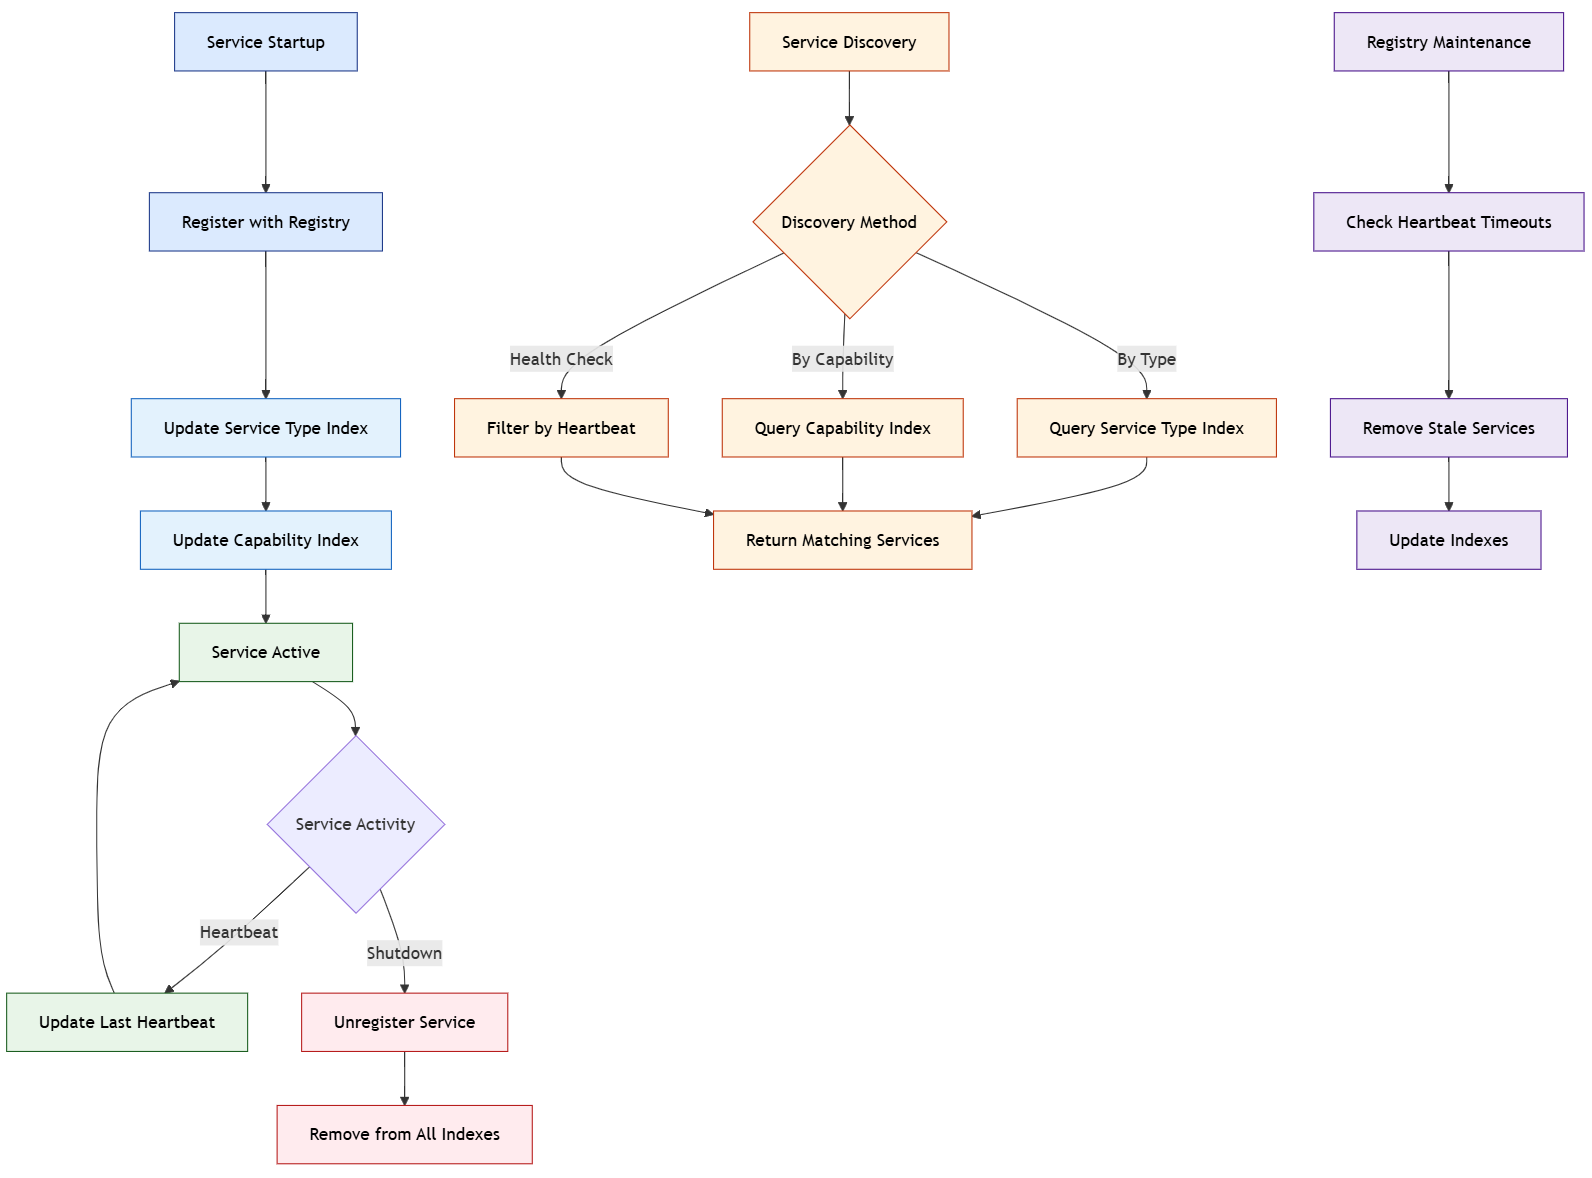

## Step-by-Step Code Breakdown
### Service Registration Data Structure
- Service Registration Class defines the complete information needed for service discovery including unique ID, name, type, and endpoint
- Capability Tracking maintains a list of what functions or services each registered agent can perform
- Health Monitoring Fields include registration timestamps and last heartbeat for service liveness detection
- Metadata Support allows for extensible custom properties specific to different service types

### Service Registry Core Operations
#### Service Registration Process
- Unique Service Identification ensures each service has a distinct identifier in the system
- Multi-index Maintenance automatically updates both service type and capability indexes during registration
- Error Handling provides graceful failure handling if registration encounters issues
- Audit Logging tracks all registration activities for system monitoring

#### Service Discovery Mechanisms
- Type-based Discovery allows finding all services of a specific category (e.g., all calculator services)
- Capability-based Discovery enables finding services that offer specific functions regardless of their type
- Health-aware Filtering ensures only responsive services are returned in discovery results

#### Health Monitoring System
- Heartbeat Updates allow services to periodically indicate they are still active and healthy
- Timeout Configuration defines how long to wait before considering a service unresponsive
- Healthy Service Filtering provides a method to retrieve only services with recent heartbeats
- Automatic Cleanup removes stale services that haven't updated their heartbeat within the timeout period

#### Service Removal Process
- Complete Unregistration removes services from all indexes and the main registry
- Index Maintenance ensures service type and capability indexes are properly updated during removal
- Stale Service Detection automatically identifies and removes services that have stopped responding
- Resource Cleanup prevents registry bloat by removing inactive service entries

### Connecting to the Lecture
- Service Discovery Patterns: Implements the directory-based discovery pattern discussed in distributed systems lectures
- Health Monitoring: Demonstrates practical heartbeat mechanisms for detecting service failures in real-time systems
- Indexing Strategies: Shows how multiple indexes can optimize different types of service lookup operations
- Fault Tolerance: The automatic cleanup of stale services connects to lecture topics about self-healing systems
- Metadata Management: The extensible metadata system supports the flexible service description concepts covered in API design
- Registry Consistency: The coordinated index updates demonstrate maintaining data consistency across multiple data structures
- System Scalability: The efficient indexing approaches support the scalability requirements discussed for large agent ecosystems

In [4]:
# EXERCISE 3: SERVICE DISCOVERY AND REGISTRY

@dataclass
class ServiceRegistration:
    """Service registration information"""
    service_id: str
    service_name: str
    service_type: str
    endpoint: str
    capabilities: List[str]
    health_check_url: Optional[str]
    metadata: Dict[str, Any]
    registered_at: float
    last_heartbeat: float

class ServiceRegistry:
    """Service registry for agent ecosystem"""
    
    def __init__(self):
        self.services: Dict[str, ServiceRegistration] = {}
        self.service_types: Dict[str, List[str]] = {}
        self.capability_index: Dict[str, List[str]] = {}
        self.heartbeat_timeout = 300  # 5 minutes
    
    def register_service(self, registration: ServiceRegistration) -> bool:
        """Register a service with the registry"""
        try:
            self.services[registration.service_id] = registration
            
            # Update service type index
            if registration.service_type not in self.service_types:
                self.service_types[registration.service_type] = []
            self.service_types[registration.service_type].append(registration.service_id)
            
            # Update capability index
            for capability in registration.capabilities:
                if capability not in self.capability_index:
                    self.capability_index[capability] = []
                self.capability_index[capability].append(registration.service_id)
            
            logger.info(f"Service {registration.service_name} registered with ID {registration.service_id}")
            return True
        except Exception as e:
            logger.error(f"Failed to register service {registration.service_id}: {e}")
            return False
    
    def unregister_service(self, service_id: str) -> bool:
        """Unregister a service from the registry"""
        if service_id not in self.services:
            return False
        
        registration = self.services[service_id]
        
        # Remove from service type index
        if registration.service_type in self.service_types:
            self.service_types[registration.service_type] = [
                sid for sid in self.service_types[registration.service_type] 
                if sid != service_id
            ]
        
        # Remove from capability index
        for capability in registration.capabilities:
            if capability in self.capability_index:
                self.capability_index[capability] = [
                    sid for sid in self.capability_index[capability] 
                    if sid != service_id
                ]
        
        del self.services[service_id]
        logger.info(f"Service {service_id} unregistered")
        return True
    
    def discover_services_by_type(self, service_type: str) -> List[ServiceRegistration]:
        """Discover services by type"""
        service_ids = self.service_types.get(service_type, [])
        return [self.services[sid] for sid in service_ids if sid in self.services]
    
    def discover_services_by_capability(self, capability: str) -> List[ServiceRegistration]:
        """Discover services by capability"""
        service_ids = self.capability_index.get(capability, [])
        return [self.services[sid] for sid in service_ids if sid in self.services]
    
    def update_heartbeat(self, service_id: str) -> bool:
        """Update service heartbeat"""
        if service_id in self.services:
            self.services[service_id].last_heartbeat = time.time()
            return True
        return False
    
    def get_healthy_services(self) -> List[ServiceRegistration]:
        """Get list of healthy services (recent heartbeat)"""
        current_time = time.time()
        healthy_services = []
        
        for service in self.services.values():
            if current_time - service.last_heartbeat < self.heartbeat_timeout:
                healthy_services.append(service)
        
        return healthy_services
    
    def cleanup_stale_services(self):
        """Remove services with stale heartbeats"""
        current_time = time.time()
        stale_services = []
        
        for service_id, service in self.services.items():
            if current_time - service.last_heartbeat > self.heartbeat_timeout:
                stale_services.append(service_id)
        
        for service_id in stale_services:
            logger.warning(f"Removing stale service: {service_id}")
            self.unregister_service(service_id)


### Short Description
This code implements a sophisticated multi-agent workflow orchestration system that coordinates complex tasks across multiple specialized AI agents. It demonstrates dependency management, agent selection, and sequential execution of workflow steps while handling inter-agent dependencies and result propagation throughout the workflow lifecycle.

### Code Logic and Flow: High-Level Overview
The orchestration system manages complex workflows composed of individual steps that must be executed by different specialized agents. It calculates execution order based on step dependencies, discovers suitable agents for each task, executes steps in the correct sequence while passing results between dependent steps, and maintains comprehensive tracking of workflow execution status and results.

### Visual Flowchart
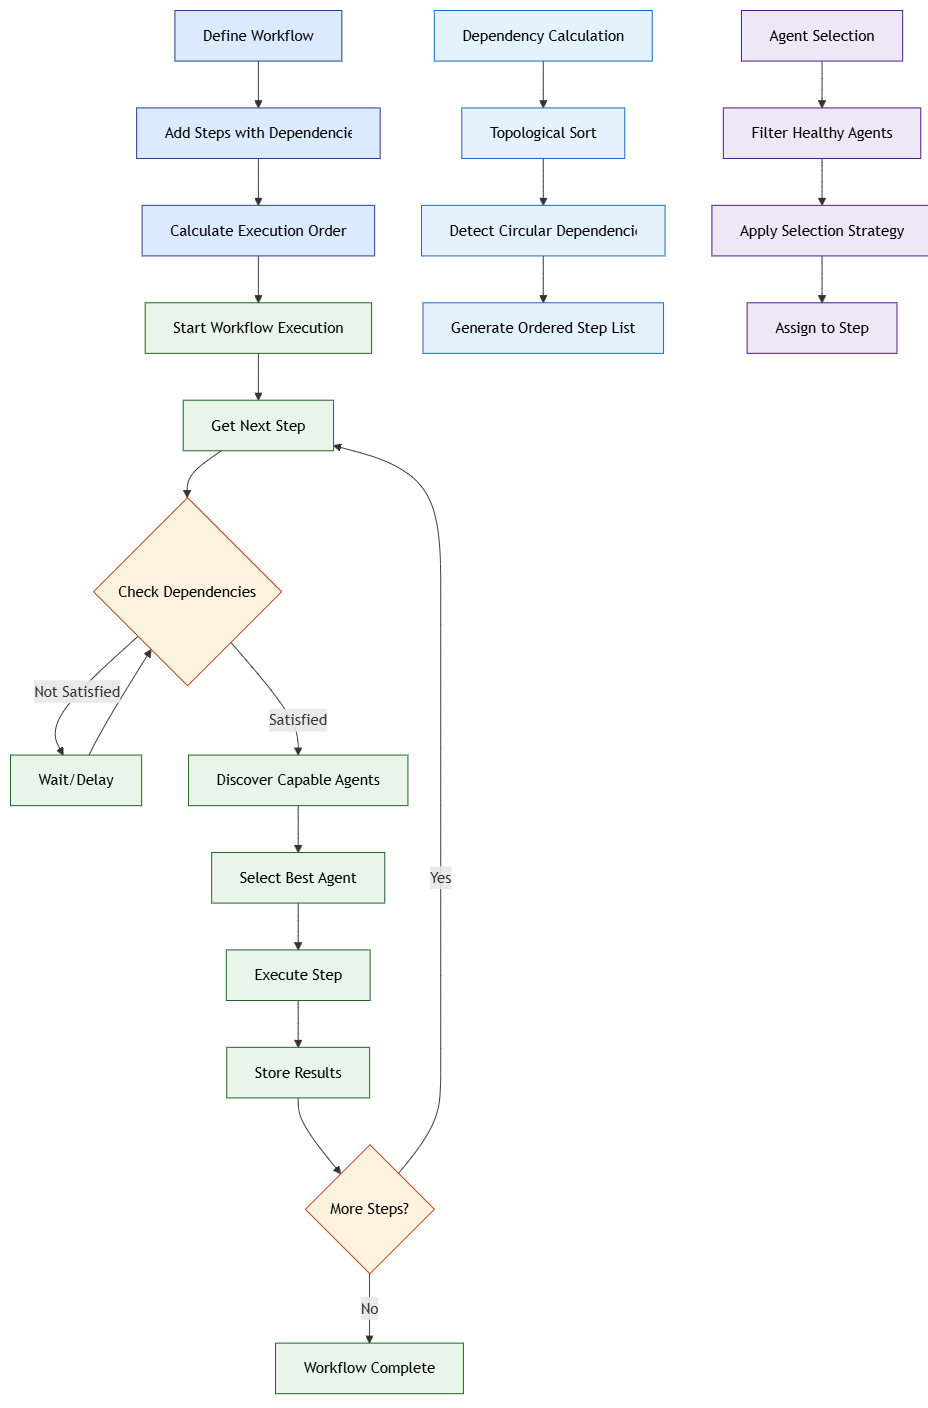

## Step-by-Step Code Breakdown
## Workflow Definition Structure
### Individual Workflow Steps
- Step Identification uses unique IDs to track each step throughout execution
- Agent Type Specification defines what kind of agent can execute each step
- Capability Requirements specify the exact functionality needed from the assigned agent
- Dependency Management tracks which steps must complete before current step can begin
- Execution Status Tracking monitors progress from pending through completion
- Result Storage preserves output for use in dependent steps

### Workflow Container
- Workflow Metadata includes unique ID and descriptive name for tracking
- Step Collection maintains all steps in the workflow with easy access
- Execution Order Calculation determines optimal step sequence based on dependencies
- Result Aggregation collects outputs from all steps for final workflow result

## Orchestration Engine
### Workflow Execution Controller
- Active Workflow Management tracks currently running workflows
- Historical Tracking maintains records of completed workflows for analysis
- Status Transition Handling manages workflow state changes throughout lifecycle

### Dependency Resolution System
- Dependency Satisfaction Checking verifies all prerequisite steps have completed
- Result Propagation ensures outputs from previous steps are available to dependent steps
- Execution Blocking prevents steps from running until dependencies are met

### Agent Discovery and Selection
- Capability-based Discovery uses the service registry to find agents with required skills
- Health Filtering ensures only responsive agents are considered for assignment
- Selection Strategy implements algorithms for choosing the most suitable agent (currently simple first-available)

### Step Execution Management
- Parameter Enhancement automatically injects dependency results into step parameters
- Message Construction creates proper A2A communication messages for agent requests
- Response Handling processes agent responses and extracts step results
- Error Management handles failures at individual step level

## Execution Flow Management
### Topological Sorting Algorithm
- Dependency Graph Analysis builds execution order based on step relationships
- Circular Dependency Detection identifies and prevents infinite execution loops
- Optimal Order Calculation ensures efficient parallel execution where possible

### Result Chain Management
- Intermediate Result Storage preserves step outputs for dependency resolution
- Result Passing automatically provides previous step results to dependent steps
- Final Result Aggregation combines all step results into comprehensive workflow output

### Connecting to the Lecture
- Workflow Patterns: Implements the sequential orchestration pattern discussed in multi-agent system design lectures
- Dependency Management: Demonstrates practical implementation of the directed acyclic graph (DAG) concepts for workflow scheduling
- Resource Allocation: The agent selection process connects to lecture topics about optimal resource utilization in distributed systems
- Error Propagation: Shows how step failures affect dependent steps and overall workflow success
- State Management: The comprehensive status tracking implements the state machine patterns covered in workflow execution theory
- Service Discovery Integration: Combines with the registry system to demonstrate dynamic agent capability lookup
- Execution Optimization: The topological sorting illustrates computational efficiency concepts for complex dependency resolution

In [5]:
# EXERCISE 4: MULTI-AGENT ORCHESTRATION PATTERNS

class WorkflowStep:
    """Individual step in a multi-agent workflow"""
    
    def __init__(self, step_id: str, agent_type: str, capability: str, 
                 parameters: Dict[str, Any], dependencies: List[str] = None):
        self.step_id = step_id
        self.agent_type = agent_type
        self.capability = capability
        self.parameters = parameters
        self.dependencies = dependencies or []
        self.status = "pending"
        self.result = None
        self.assigned_agent = None

class AgentWorkflow:
    """Multi-agent workflow definition and execution"""
    
    def __init__(self, workflow_id: str, name: str):
        self.workflow_id = workflow_id
        self.name = name
        self.steps: Dict[str, WorkflowStep] = {}
        self.execution_order: List[str] = []
        self.status = "created"
        self.results: Dict[str, Any] = {}
    
    def add_step(self, step: WorkflowStep):
        """Add a step to the workflow"""
        self.steps[step.step_id] = step
        self._calculate_execution_order()
    
    def _calculate_execution_order(self):
        """Calculate execution order based on dependencies"""
        # Simple topological sort
        visited = set()
        temp_visited = set()
        order = []
        
        def visit(step_id: str):
            if step_id in temp_visited:
                raise ValueError("Circular dependency detected")
            if step_id not in visited:
                temp_visited.add(step_id)
                step = self.steps[step_id]
                for dep in step.dependencies:
                    if dep in self.steps:
                        visit(dep)
                temp_visited.remove(step_id)
                visited.add(step_id)
                order.append(step_id)
        
        for step_id in self.steps:
            if step_id not in visited:
                visit(step_id)
        
        self.execution_order = order

class MultiAgentOrchestrator:
    """Orchestrates multi-agent workflows"""
    
    def __init__(self, communication_bus: A2ACommunicationBus, 
                 service_registry: ServiceRegistry):
        self.communication_bus = communication_bus
        self.service_registry = service_registry
        self.active_workflows: Dict[str, AgentWorkflow] = {}
        self.workflow_history: List[AgentWorkflow] = []
    
    async def execute_workflow(self, workflow: AgentWorkflow) -> Dict[str, Any]:
        """Execute a multi-agent workflow"""
        workflow.status = "running"
        self.active_workflows[workflow.workflow_id] = workflow
        
        logger.info(f"Starting workflow execution: {workflow.name}")
        
        try:
            for step_id in workflow.execution_order:
                step = workflow.steps[step_id]
                
                # Check dependencies
                if not self._dependencies_satisfied(workflow, step):
                    raise ValueError(f"Dependencies not satisfied for step {step_id}")
                
                # Find suitable agent
                suitable_agents = self.service_registry.discover_services_by_capability(
                    step.capability
                )
                
                if not suitable_agents:
                    raise ValueError(f"No agents found with capability: {step.capability}")
                
                # Select best agent (simple selection by load)
                selected_agent = self._select_best_agent(suitable_agents)
                step.assigned_agent = selected_agent.service_id
                
                # Execute step
                step_result = await self._execute_step(workflow, step)
                step.result = step_result
                step.status = "completed"
                
                # Store result for dependent steps
                workflow.results[step_id] = step_result
                
                logger.info(f"Completed step {step_id} in workflow {workflow.workflow_id}")
            
            workflow.status = "completed"
            return {
                "workflow_id": workflow.workflow_id,
                "status": "completed",
                "results": workflow.results
            }
            
        except Exception as e:
            workflow.status = "failed"
            logger.error(f"Workflow {workflow.workflow_id} failed: {e}")
            return {
                "workflow_id": workflow.workflow_id,
                "status": "failed",
                "error": str(e)
            }
        finally:
            # Move to history
            self.workflow_history.append(workflow)
            if workflow.workflow_id in self.active_workflows:
                del self.active_workflows[workflow.workflow_id]
    
    def _dependencies_satisfied(self, workflow: AgentWorkflow, step: WorkflowStep) -> bool:
        """Check if all dependencies for a step are satisfied"""
        for dep_id in step.dependencies:
            if dep_id not in workflow.results:
                return False
        return True
    
    def _select_best_agent(self, agents: List[ServiceRegistration]) -> ServiceRegistration:
        """Select the best agent for a task (simple load-based selection)"""
        # In a real implementation, this would consider load, performance, cost, etc.
        healthy_agents = [agent for agent in agents 
                         if time.time() - agent.last_heartbeat < 300]
        
        if not healthy_agents:
            raise ValueError("No healthy agents available")
        
        # Simple selection - return first available
        return healthy_agents[0]
    
    async def _execute_step(self, workflow: AgentWorkflow, step: WorkflowStep) -> Any:
        """Execute a single workflow step"""
        # Prepare parameters with dependency results
        enhanced_parameters = step.parameters.copy()
        for dep_id in step.dependencies:
            enhanced_parameters[f"dep_{dep_id}"] = workflow.results.get(dep_id)
        
        # Create A2A message for the assigned agent
        message = A2AMessage(
            message_type=A2AMessageType.REQUEST,
            message_id=str(uuid.uuid4()),
            sender_agent_id="orchestrator",
            recipient_agent_id=step.assigned_agent,
            timestamp=time.time(),
            payload={
                "capability": step.capability,
                "parameters": enhanced_parameters,
                "workflow_id": workflow.workflow_id,
                "step_id": step.step_id
            },
            requires_response=True
        )
        
        # In a real implementation, this would wait for the actual response
        # For demonstration, we'll simulate the execution
        await asyncio.sleep(0.1)  # Simulate processing time
        
        return {
            "step_id": step.step_id,
            "status": "success",
            "result": f"Executed {step.capability} with parameters {enhanced_parameters}"
        }


### Short Description
This code demonstrates a complete agentic ecosystem integrating all previous components into a unified system. It showcases service registration, inter-agent communication, workflow orchestration, and protocol interoperability, providing an end-to-end example of how multiple AI agents can collaborate seamlessly in a distributed environment.

### Code Logic and Flow: High-Level Overview
The demonstration systematically builds and tests a complete agentic ecosystem by sequentially setting up each component, registering services, establishing communication channels, and executing complex multi-agent workflows. It shows how MCP providers, A2A communication, service discovery, and workflow orchestration work together to create a cohesive system where agents can discover each other's capabilities, communicate effectively, and collaborate on complex tasks.

### Visual Flowchart
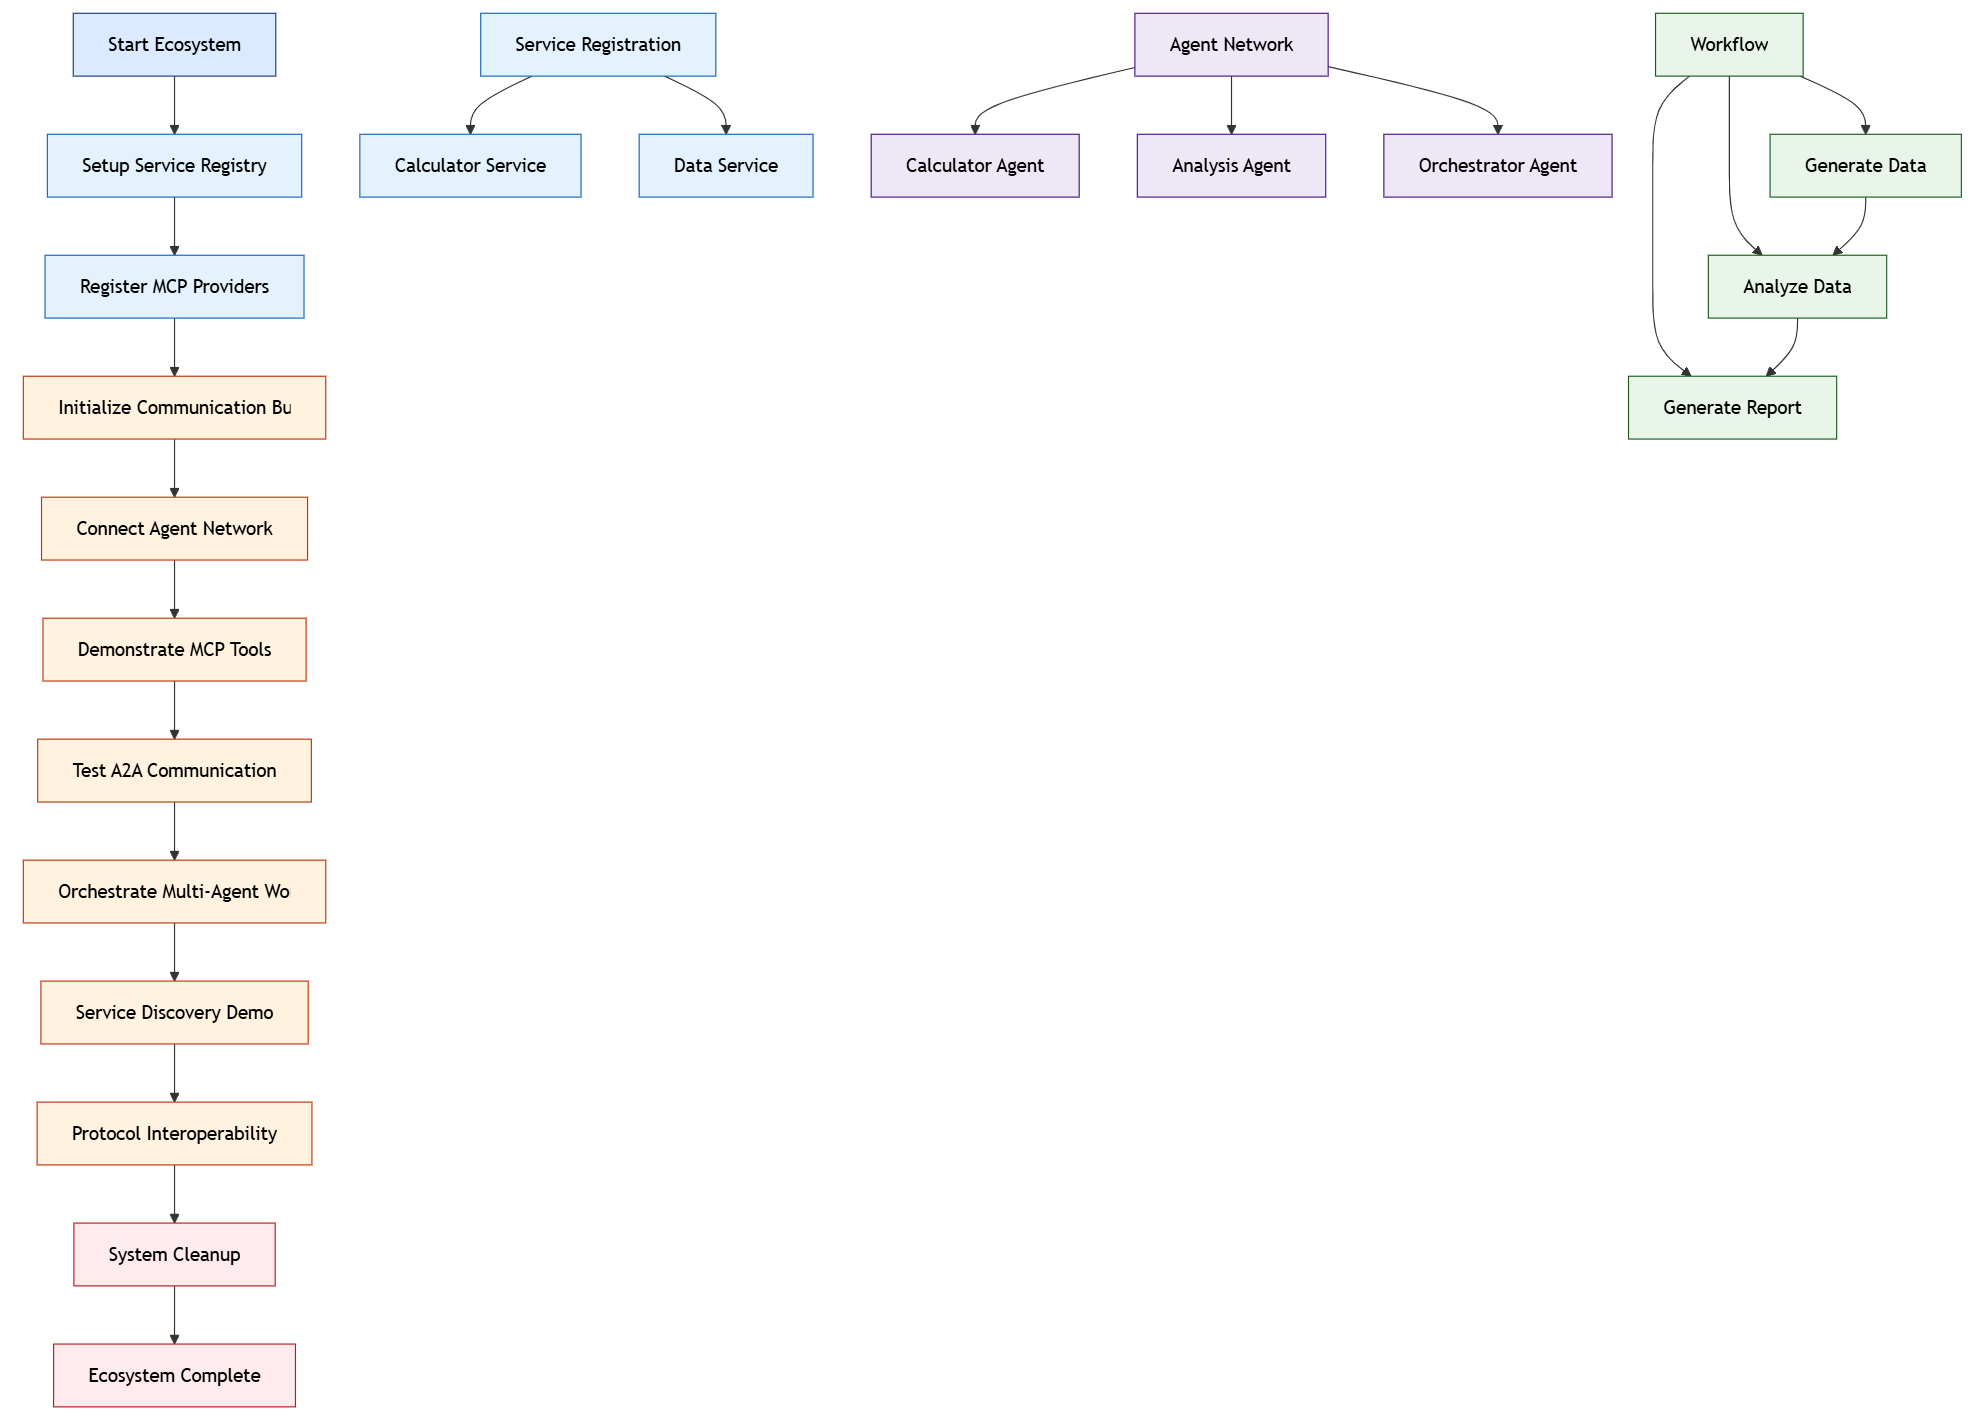

## Step-by-Step Code Breakdown
## Ecosystem Initialization Phase
### Service Registry Setup
- Registry Instantiation creates the central service directory for the ecosystem
- MCP Provider Registration converts protocol providers into discoverable services
- Capability Indexing automatically builds searchable indexes of all available services
- Health Status Initialization sets up initial heartbeat timestamps for all services

### Communication Infrastructure Establishment
- Communication Bus Startup initializes the message routing system
- Agent Network Creation instantiates specialized agents with different capabilities
- Bus Connection Protocol links all agents to the central communication system
- Network Verification confirms successful agent registration and connectivity

## Protocol Demonstration Phase
### MCP Tool Interaction
- Protocol Initialization demonstrates the MCP handshake process between clients and providers
- Tool Discovery shows how clients can query available tools from MCP providers
- Tool Execution tests actual tool invocation with parameter passing and result retrieval
- Response Processing handles and displays the results from MCP tool executions

### A2A Communication Testing
- Handshake Protocol demonstrates agent introduction and capability exchange
- Capability Request shows how agents can request services from other agents
- Message Routing tests the communication bus's ability to deliver messages correctly
- Response Handling processes and displays inter-agent communication results

## Workflow Orchestration Phase
### Complex Workflow Design
- Multi-step Pipeline creates a sequential workflow with data dependencies
- Dependency Definition establishes relationships between workflow steps
- Execution Order Calculation automatically determines optimal step sequence
- Parameter Configuration sets up appropriate inputs for each workflow step

### Workflow Execution
- Orchestrator Initialization sets up the workflow management system
- Step-by-step Execution processes each workflow step in dependency order
- Agent Assignment dynamically assigns suitable agents to each step
- Result Aggregation collects and combines outputs from all workflow steps

## Advanced Features Demonstration
### Service Discovery System
- Capability-based Lookup demonstrates finding services by specific functionalities
- Type-based Discovery shows how to find all services of a particular category
- Health Monitoring tests the system's ability to identify responsive services
- Service Catalog Browsing displays all available services in the ecosystem

### Protocol Interoperability
- MCP-to-A2A Bridging demonstrates protocol translation between different standards
- Message Format Conversion shows how messages can be adapted between protocols
- Cross-protocol Communication enables interaction between systems using different standards
- Protocol Translation Validation confirms that message integrity is maintained during conversion

## System Management
### Resource Cleanup
- Orderly Shutdown demonstrates proper termination of all system components
- Resource Deallocation ensures all connections and threads are properly closed
- State Preservation maintains historical data for future analysis
- System Verification confirms successful completion of all demonstration phases

### Connecting to the Lecture
- System Integration: Demonstrates the complete integration of multiple agentic AI patterns discussed throughout the course
- Protocol Layering: Shows how different communication protocols (MCP, A2A) can coexist and interact in a single ecosystem
- Scalability Patterns: The service registry and communication bus implement the scalable architecture concepts covered in distributed systems lectures
- Interoperability Standards: The protocol bridging demonstrates real-world solutions for integrating heterogeneous AI systems
- Fault Tolerance: The health monitoring and service discovery show practical implementations of resilience patterns
- Workflow Composition: The multi-step workflow illustrates the choreography vs orchestration concepts from multi-agent system design
- Real-world Deployment: The comprehensive demonstration mirrors production-ready agentic system architectures discussed in case studies

In [6]:
# EXERCISE 5: COMPREHENSIVE ECOSYSTEM DEMONSTRATION

async def demonstrate_agentic_ecosystem():
    """Comprehensive demonstration of the 2025 Agentic Ecosystem"""
    
    print("=" * 70)
    print("2025 AGENTIC ECOSYSTEM DEMONSTRATION")
    print("=" * 70)
    
    # 1. Setup Service Registry
    print("\n1. SETTING UP SERVICE REGISTRY")
    print("-" * 40)
    
    registry = ServiceRegistry()
    
    # Register MCP providers as services
    calc_provider = CalculatorMCPProvider()
    data_provider = DataMCPProvider()
    
    calc_service = ServiceRegistration(
        service_id="calc_service_001",
        service_name="Calculator MCP Service",
        service_type="computational",
        endpoint="mcp://calculator",
        capabilities=list(calc_provider.capabilities),
        health_check_url=None,
        metadata={"version": "1.0", "load": 0.1},
        registered_at=time.time(),
        last_heartbeat=time.time()
    )
    
    data_service = ServiceRegistration(
        service_id="data_service_001",
        service_name="Data Access MCP Service",
        service_type="data",
        endpoint="mcp://data",
        capabilities=list(data_provider.capabilities),
        health_check_url=None,
        metadata={"version": "1.0", "load": 0.2},
        registered_at=time.time(),
        last_heartbeat=time.time()
    )
    
    registry.register_service(calc_service)
    registry.register_service(data_service)
    
    print(f"Registered services: {len(registry.services)}")
    print(f"Available capabilities: {list(registry.capability_index.keys())}")
    
    # 2. Setup A2A Communication
    print("\n2. SETTING UP A2A COMMUNICATION")
    print("-" * 40)
    
    comm_bus = A2ACommunicationBus()
    comm_bus.start()
    
    # Create agents
    calc_agent = CalculatorAgent("calc_agent_001")
    analysis_agent = DataAnalysisAgent("analysis_agent_001")
    orchestrator = OrchestratorAgent("orchestrator_001")
    
    # Connect agents to bus
    calc_agent.connect_to_bus(comm_bus)
    analysis_agent.connect_to_bus(comm_bus)
    orchestrator.connect_to_bus(comm_bus)
    
    print(f"Connected agents: {len(comm_bus.registered_agents)}")
    
    # 3. Demonstrate MCP Tool Interaction
    print("\n3. MCP TOOL INTERACTION DEMONSTRATION")
    print("-" * 40)
    
    # Create MCP messages
    init_message = MCPMessage(
        message_type=MCPMessageType.INITIALIZE,
        message_id=str(uuid.uuid4()),
        sender_id="client_001",
        recipient_id=calc_provider.provider_id,
        timestamp=time.time(),
        payload={"client_info": "Demo client"}
    )
    
    response = await calc_provider.process_message(init_message)
    print(f"MCP Initialize Response: {response.payload['name']}")
    print(f"Available tools: {list(response.payload['tools'].keys())}")
    
    # Test tool execution
    tool_call_message = MCPMessage(
        message_type=MCPMessageType.TOOL_CALL,
        message_id=str(uuid.uuid4()),
        sender_id="client_001",
        recipient_id=calc_provider.provider_id,
        timestamp=time.time(),
        payload={
            "tool_name": "arithmetic",
            "parameters": {
                "operation": "add",
                "operands": [10, 20, 30]
            }
        }
    )
    
    tool_response = await calc_provider.process_message(tool_call_message)
    print(f"Tool execution result: {tool_response.payload}")
    
    # 4. Demonstrate A2A Communication
    print("\n4. A2A COMMUNICATION DEMONSTRATION")
    print("-" * 40)
    
    # Handshake between agents
    handshake_msg = A2AMessage(
        message_type=A2AMessageType.HANDSHAKE,
        message_id=str(uuid.uuid4()),
        sender_agent_id=calc_agent.agent_id,
        recipient_agent_id=analysis_agent.agent_id,
        timestamp=time.time(),
        payload={"greeting": "Hello from calculator agent"}
    )
    
    calc_agent.send_message(handshake_msg)
    await asyncio.sleep(0.5)  # Allow message processing
    
    # Request capability from another agent
    request_msg = A2AMessage(
        message_type=A2AMessageType.REQUEST,
        message_id=str(uuid.uuid4()),
        sender_agent_id=calc_agent.agent_id,
        recipient_agent_id=analysis_agent.agent_id,
        timestamp=time.time(),
        payload={
            "capability": "data_analysis",
            "parameters": {
                "data": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
                "analysis_type": "summary"
            }
        },
        requires_response=True
    )
    
    calc_agent.send_message(request_msg)
    await asyncio.sleep(0.5)  # Allow message processing
    
    # 5. Multi-Agent Workflow Orchestration
    print("\n5. MULTI-AGENT WORKFLOW ORCHESTRATION")
    print("-" * 40)
    
    workflow_orchestrator = MultiAgentOrchestrator(comm_bus, registry)
    
    # Create a complex workflow
    workflow = AgentWorkflow("workflow_001", "Data Processing Pipeline")
    
    # Step 1: Generate data
    generate_step = WorkflowStep(
        step_id="generate_data",
        agent_type="computational",
        capability="mathematical_operations",
        parameters={
            "operation": "generate_sequence",
            "count": 100
        }
    )
    
    # Step 2: Analyze data (depends on step 1)
    analyze_step = WorkflowStep(
        step_id="analyze_data",
        agent_type="analytical",
        capability="data_analysis",
        parameters={
            "analysis_type": "summary"
        },
        dependencies=["generate_data"]
    )
    
    # Step 3: Generate report (depends on step 2)
    report_step = WorkflowStep(
        step_id="generate_report",
        agent_type="coordinator",
        capability="workflow_orchestration",
        parameters={
            "report_type": "summary"
        },
        dependencies=["analyze_data"]
    )
    
    workflow.add_step(generate_step)
    workflow.add_step(analyze_step)
    workflow.add_step(report_step)
    
    print(f"Workflow execution order: {workflow.execution_order}")
    
    # Execute workflow
    workflow_result = await workflow_orchestrator.execute_workflow(workflow)
    print(f"Workflow result: {workflow_result}")
    
    # 6. Service Discovery Demonstration
    print("\n6. SERVICE DISCOVERY DEMONSTRATION")
    print("-" * 40)
    
    # Discover services by capability
    math_services = registry.discover_services_by_capability("mathematical_operations")
    print(f"Services with mathematical capabilities: {len(math_services)}")
    
    for service in math_services:
        print(f"  - {service.service_name} ({service.service_id})")
    
    # Discover services by type
    computational_services = registry.discover_services_by_type("computational")
    print(f"Computational services: {len(computational_services)}")
    
    # Health check
    healthy_services = registry.get_healthy_services()
    print(f"Healthy services: {len(healthy_services)}")
    
    # 7. Protocol Interoperability
    print("\n7. PROTOCOL INTEROPERABILITY DEMONSTRATION")
    print("-" * 40)
    
    # Demonstrate MCP-to-A2A bridge
    async def mcp_to_a2a_bridge(mcp_message: MCPMessage) -> A2AMessage:
        """Bridge MCP messages to A2A protocol"""
        return A2AMessage(
            message_type=A2AMessageType.REQUEST,
            message_id=str(uuid.uuid4()),
            sender_agent_id="mcp_bridge",
            recipient_agent_id="target_agent",
            timestamp=time.time(),
            payload={
                "original_protocol": "MCP",
                "original_message_type": mcp_message.message_type.value,
                "payload": mcp_message.payload
            }
        )
    
    # Convert MCP tool call to A2A request
    a2a_message = await mcp_to_a2a_bridge(tool_call_message)
    print(f"MCP->A2A Bridge: {a2a_message.message_type.value}")
    
    # Cleanup
    comm_bus.stop()
    
    print("\n" + "=" * 70)
    print("ECOSYSTEM DEMONSTRATION COMPLETE")
    print("=" * 70)


### Short Description
This code provides three structured student exercises that build upon the core agentic AI concepts. Each exercise challenges students to extend the basic framework with advanced functionality including custom MCP providers, consensus mechanisms for multi-agent systems, and dynamic service mesh patterns for improved reliability and performance.

### Code Logic and Flow: High-Level Overview
The exercises progress from individual component extension to system-level architecture patterns. Students start by creating a file operations provider, then implement consensus mechanisms for multi-agent decision making, and finally build a service mesh with load balancing and fault tolerance. Each exercise builds on concepts from the previous ones, creating a comprehensive learning path from basic tool implementation to distributed system design.

### Visual Flowchart
```mermaid
graph TD
    A[Student Exercises] --> B[Exercise 1: File MCP Provider]
    A --> C[Exercise 2: Consensus Agent]
    A --> D[Exercise 3: Service Mesh]
    
    B --> E[File Reading Tool]
    B --> F[File Writing Tool]
    B --> G[Directory Listing Tool]
    B --> H[Security & Error Handling]
    
    C --> I[Voting Mechanism]
    C --> J[Consensus Protocols]
    C --> K[Leader Election]
    C --> L[Decision Aggregation]
    
    D --> M[Load Balancing]
    D --> N[Circuit Breakers]
    D --> O[Automatic Failover]
    D --> P[Health Monitoring]
    
    E --> Q[Integration Testing]
    F --> Q
    G --> Q
    H --> Q
    I --> R[Multi-Agent Testing]
    J --> R
    K --> R
    L --> R
    M --> S[System Validation]
    N --> S
    O --> S
    P --> S

    %% --- Node Style Definitions ---
    classDef exercises fill:#ede7f6,stroke:#4a148c,color:#000,font-weight:bold;       %% Purple - exercises
    classDef tools fill:#e3f2fd,stroke:#1565c0,color:#000,font-weight:bold;          %% Light blue - tools
    classDef testing fill:#e8f5e8,stroke:#1b5e20,color:#000,font-weight:bold;        %% Green - testing/validation
    classDef main fill:#dbeafe,stroke:#1e3a8a,color:#000,font-weight:bold;           %% Blue - main node

    %% --- Apply Classes ---
    class A main;
    class B,C,D exercises;
    class E,F,G,H,I,J,K,L,M,N,O,P tools;
    class Q,R,S testing;
```

## Step-by-Step Code Breakdown
## Exercise 1: Custom MCP Provider for File Operations
### FileMCPProvider Base Structure
- Provider Initialization requires setting up the provider ID, name, and registering file operation tools
- Tool Registration involves defining file read, write, and directory listing capabilities with proper schemas
- Capability Declaration specifies that the provider offers file system operations

### File Operation Tools Implementation
- File Reading Capability should handle opening and reading files with proper encoding and error handling
- File Writing Capability needs to manage file creation, overwriting, and appending with safety checks
- Directory Listing Tool must scan directories and return structured file information
- Security Considerations should include path validation and access permission checks

### Error Handling and Security
- Input Validation ensures file paths are safe and within allowed directories
- Exception Management provides meaningful error messages for file not found, permission denied, and other common issues
- Resource Management properly closes file handles and manages system resources
- Security Boundaries prevents directory traversal attacks and unauthorized access

## Exercise 2: Advanced A2A Consensus Mechanisms
### ConsensusAgent Architecture
- Agent Initialization sets up voting state, participant tracking, and consensus protocol configuration
- Protocol Selection allows implementation of different consensus algorithms like RAFT or Byzantine fault tolerance
- Member Management tracks which agents participate in consensus decisions

### Voting and Decision Mechanisms
- Vote Initiation creates proposals with unique IDs and distributes them to participating agents
- Vote Collection gathers decisions from all participants within timeout periods
- Consensus Calculation applies the chosen protocol to determine the final decision
- Result Propagation communicates the consensus outcome back to all participants

### Advanced Consensus Features
- Leader Election implements algorithms for selecting coordinating agents in distributed decisions
- Fault Tolerance handles scenarios where some agents are unresponsive or provide conflicting responses
- Decision Aggregation combines multiple agent inputs into coherent system decisions
- State Synchronization ensures all agents maintain consistent understanding of decisions

## Exercise 3: Dynamic Service Mesh Implementation
### ServiceMesh Core Infrastructure
- Mesh Initialization sets up load balancers, circuit breakers, and service health monitors
- Service Registry Integration connects with the existing service discovery system
- Routing Table Management maintains dynamic routing information for all available services

### Load Balancing and Routing
- Algorithm Implementation provides multiple load balancing strategies (round-robin, least connections, etc.)
- Request Routing directs incoming requests to the most appropriate service instance
- Performance Monitoring tracks response times and success rates for routing decisions
- Dynamic Weight Adjustment modifies routing based on real-time service performance

### Reliability and Fault Tolerance
- Circuit Breaker Pattern prevents cascading failures by stopping requests to failing services
- Automatic Failover redirects traffic to healthy services when primary services fail
- Health Monitoring continuously checks service availability and performance
- Graceful Degradation maintains system functionality even when some services are unavailable

### Advanced Service Mesh Features
- Request Retry Logic implements smart retry mechanisms with exponential backoff
- Service Dependency Mapping tracks and visualizes relationships between different services
- Capacity Planning monitors resource usage and predicts scaling needs
- Traffic Management implements quality of service and priority-based routing

### Connecting to the Lecture
- Tool Extension Patterns: Exercise 1 demonstrates how to extend MCP frameworks with domain-specific tools, connecting to lecture topics about protocol extensibility
- Distributed Consensus: Exercise 2 implements theoretical consensus algorithms from distributed systems lectures in practical multi-agent scenarios
- System Reliability: Exercise 3 applies circuit breaker and load balancing patterns discussed in microservices architecture to agentic systems
- Fault Tolerance: All exercises incorporate error handling and recovery mechanisms covered in reliability engineering topics
- Security Considerations: Exercise 1's file operations highlight the security implications discussed in trusted execution environments
- Performance Optimization: Exercise 3's load balancing connects to lecture content about resource optimization and quality of service
- Coordination Patterns: Exercise 2's consensus mechanisms implement the multi-agent coordination strategies covered in distributed AI systems

In [7]:
# STUDENT EXERCISES

def student_exercise_1():
    """
    STUDENT EXERCISE 1: Extend MCP Provider
    Task: Create a custom MCP provider with file operations
    """
    print("\nSTUDENT EXERCISE 1: Custom MCP Provider")
    print("TODO: Implement FileMCPProvider with read/write/list capabilities")
    
    class FileMCPProvider(MCPProvider):
        """
        Student implementation needed:
        - File reading capability
        - File writing capability  
        - Directory listing capability
        - Proper error handling and security
        """
        def __init__(self):
            # STUDENT CODE HERE
            pass
        
        async def execute_tool(self, tool_name: str, parameters: Dict[str, Any]) -> Any:
            # STUDENT CODE HERE
            pass

def student_exercise_2():
    """
    STUDENT EXERCISE 2: Advanced A2A Communication Patterns
    Task: Implement consensus and voting mechanisms
    """
    print("\nSTUDENT EXERCISE 2: A2A Consensus Mechanisms")
    print("TODO: Implement consensus voting for multi-agent decisions")
    
    class ConsensusAgent(AgentNode):
        """
        Student implementation needed:
        - Voting mechanism
        - Consensus protocols (e.g., RAFT, Byzantine fault tolerance)
        - Leader election
        - Decision aggregation
        """
        def __init__(self, agent_id: str):
            # STUDENT CODE HERE
            pass
        
        def initiate_vote(self, proposal: Dict[str, Any]) -> str:
            # STUDENT CODE HERE
            pass
        
        def cast_vote(self, vote_id: str, decision: bool) -> None:
            # STUDENT CODE HERE
            pass

def student_exercise_3():
    """
    STUDENT EXERCISE 3: Dynamic Service Mesh
    Task: Implement load balancing and failover
    """
    print("\nSTUDENT EXERCISE 3: Dynamic Service Mesh")
    print("TODO: Add load balancing, circuit breakers, and failover")
    
    class ServiceMesh:
        """
        Student implementation needed:
        - Load balancing algorithms
        - Circuit breaker pattern
        - Automatic failover
        - Service health monitoring
        """
        def __init__(self):
            # STUDENT CODE HERE
            pass
        
        def route_request(self, service_type: str, request: Any) -> Any:
            # STUDENT CODE HERE
            pass
        
        def handle_service_failure(self, service_id: str) -> None:
            # STUDENT CODE HERE
            pass


### Short Description
This code implements a performance benchmarking system for evaluating the scalability and efficiency of multi-agent AI ecosystems. It measures message throughput, system responsiveness, and communication efficiency across multiple concurrent agents, providing quantitative metrics for system performance under load.

### Code Logic and Flow: High-Level Overview
The benchmarking system creates a controlled environment with multiple agents, generates a high volume of inter-agent messages, and measures how efficiently the ecosystem processes this communication load. It establishes baseline performance metrics by timing message creation, routing, and delivery across a distributed agent network, providing insights into system scalability and communication bottlenecks.

### Visual Flowchart
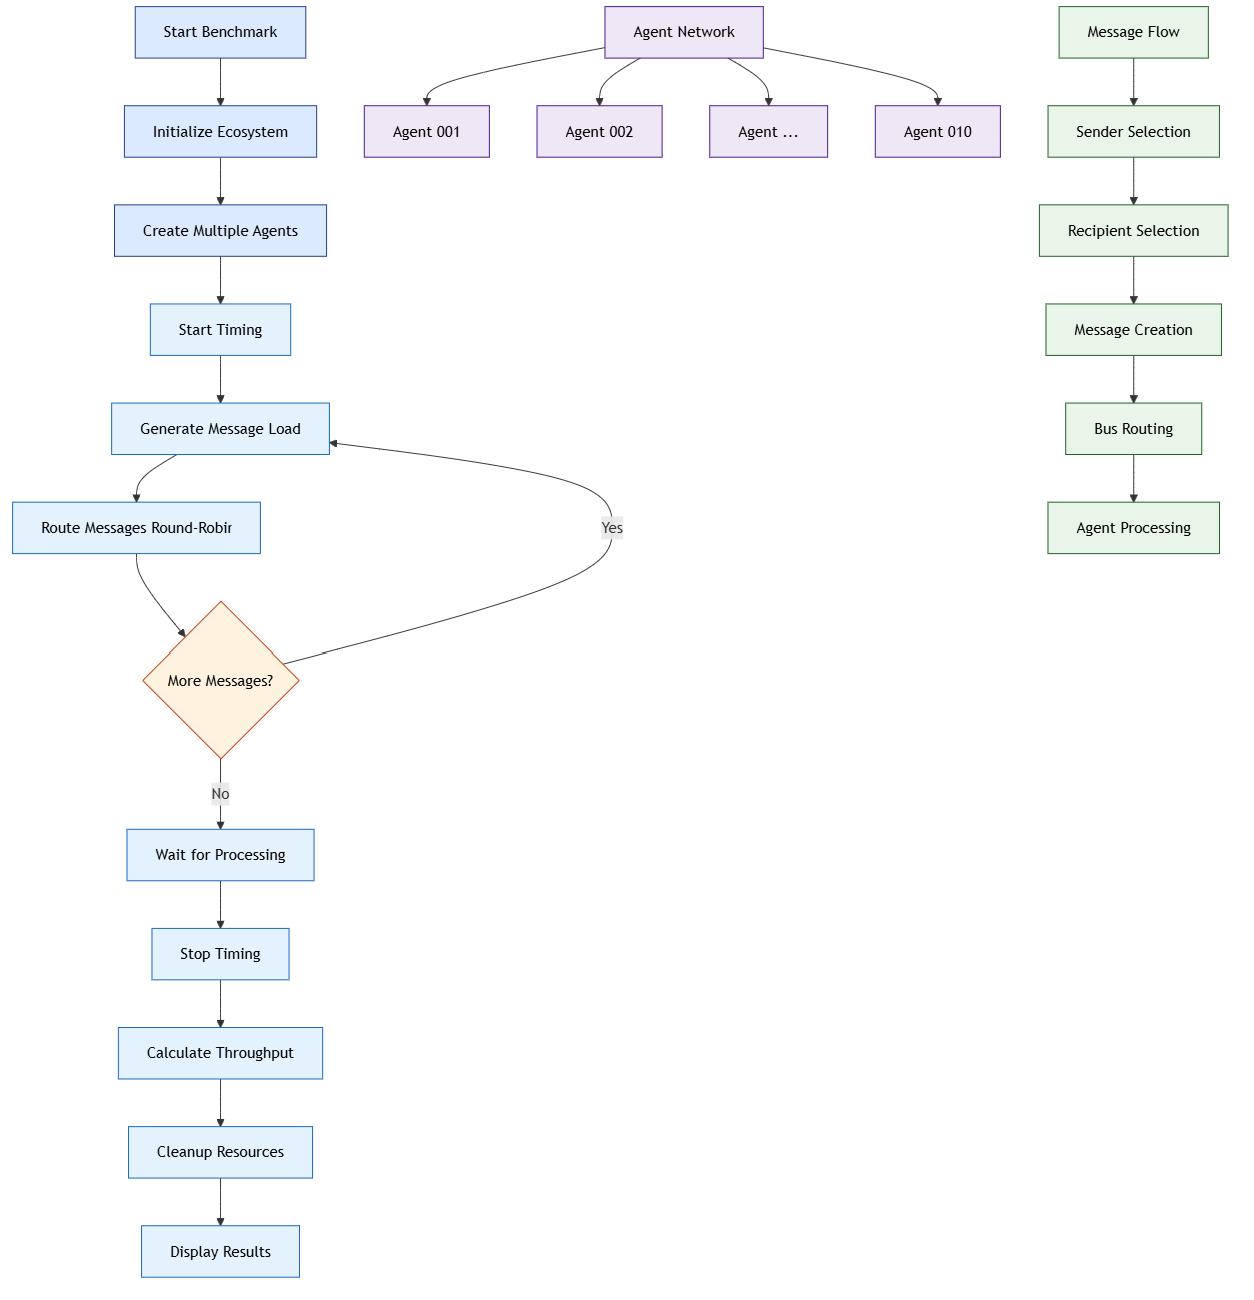

## Step-by-Step Code Breakdown

## Benchmark Environment Setup
### Ecosystem Initialization
Service Registry Creation establishes the central service directory for agent discovery
Communication Bus Startup initializes the message routing infrastructure and begins processing
Thread Management ensures the communication bus runs in the background during testing

### Agent Network Creation
Multiple Agent Instantiation creates a scalable number of calculator agents (10 in this case)
Sequential Agent Identification uses formatted IDs to ensure unique agent identifiers
Bus Connection Protocol registers each agent with the communication system
Agent Pool Management maintains references to all created agents for message distribution

## Performance Measurement Execution
### Message Load Generation
Controlled Message Count generates a specific number of messages (1000) for consistent testing
Round-Robin Distribution alternates senders and recipients to simulate realistic communication patterns
Sequential Message Creation builds messages with proper headers and payloads
Immediate Message Submission sends each message to the bus as it's created to measure processing under load

### Timing and Measurement
Precise Start Timing captures the exact moment before message generation begins
Processing Window allows sufficient time for all messages to be routed and processed
Accurate End Timing measures when all message processing should be complete
Duration Calculation computes the total time taken for the entire message load

## Metrics Calculation and Analysis
### Throughput Calculation
Message Count Basis uses the fixed number of generated messages as the numerator
Time Duration Denominator calculates the actual processing time from start to completion
Performance Metric computes messages per second as the primary throughput indicator
Result Formatting presents the throughput in a human-readable format with decimal precision

### System Resource Management
Orderly Communication Shutdown stops the message bus after benchmarking completes
Agent Reference Maintenance keeps agents in memory during testing but allows garbage collection afterward
Clean Resource Deallocation ensures no lingering threads or connections after benchmark completion

## Benchmark Validation
### Test Message Characteristics
Standardized Payload uses consistent message content to ensure comparable processing times
Proper Message Headers includes all required fields like message type, IDs, and timestamps
Realistic Routing Patterns simulates actual agent communication rather than synthetic patterns
Response Requirement Consideration accounts for whether messages require responses in timing

### Processing Completion Assurance
Adequate Wait Period allows sufficient time for all queued messages to be processed
Background Processing Accommodation considers that message routing happens asynchronously
System Stabilization ensures all agents have processed their incoming messages before final timing

## Connecting to the Lecture
System Scalability: Demonstrates practical measurement of how agent ecosystems perform under increasing load, connecting to lecture topics about distributed system scaling
Message Throughput: Provides quantitative metrics for the communication efficiency concepts discussed in multi-agent system design lectures
Performance Bottlenecks: Helps identify where slowdowns occur in agent communication, relating to lecture content about system optimization
Load Testing Patterns: Implements standardized benchmarking approaches covered in software performance engineering
Resource Utilization: Shows how to measure system efficiency, connecting to lectures about optimizing computational resources in AI systems
Concurrency Handling: Tests the framework's ability to manage simultaneous agent communications, relevant to parallel processing discussions
Quality of Service: The throughput metrics relate to service level agreement concepts covered in production system deployment lectures

In [8]:
# PERFORMANCE BENCHMARKS

async def benchmark_ecosystem_performance():
    """Benchmark the performance of the agentic ecosystem"""
    print("\nPERFORMANCE BENCHMARKS")
    print("-" * 40)
    
    # Setup
    registry = ServiceRegistry()
    comm_bus = A2ACommunicationBus()
    comm_bus.start()
    
    # Create multiple agents
    agents = []
    for i in range(10):
        agent = CalculatorAgent(f"calc_agent_{i:03d}")
        agent.connect_to_bus(comm_bus)
        agents.append(agent)
    
    # Benchmark message throughput
    start_time = time.time()
    message_count = 1000
    
    for i in range(message_count):
        sender = agents[i % len(agents)]
        recipient = agents[(i + 1) % len(agents)]
        
        message = A2AMessage(
            message_type=A2AMessageType.REQUEST,
            message_id=str(uuid.uuid4()),
            sender_agent_id=sender.agent_id,
            recipient_agent_id=recipient.agent_id,
            timestamp=time.time(),
            payload={"test": "benchmark"}
        )
        
        sender.send_message(message)
    
    await asyncio.sleep(2)  # Allow processing
    end_time = time.time()
    
    throughput = message_count / (end_time - start_time)
    print(f"Message throughput: {throughput:.2f} messages/second")
    
    # Cleanup
    comm_bus.stop()


### Short Description
This code provides a compatibility layer that enables asynchronous agentic AI demonstrations to run seamlessly in both Jupyter notebooks and standalone Python environments. It handles the different event loop management requirements between interactive notebook environments and traditional Python scripts, ensuring consistent execution across platforms.

### Code Logic and Flow: High-Level Overview
The compatibility system first attempts to detect the current execution environment by checking for running event loops and available libraries. It then applies the appropriate execution strategy: using existing loops in Jupyter with necessary patches, creating new loops for standalone Python, or providing graceful fallbacks when dependencies are missing. This ensures that asynchronous agentic demonstrations work consistently regardless of the user's development environment.

### Visual Flowchart
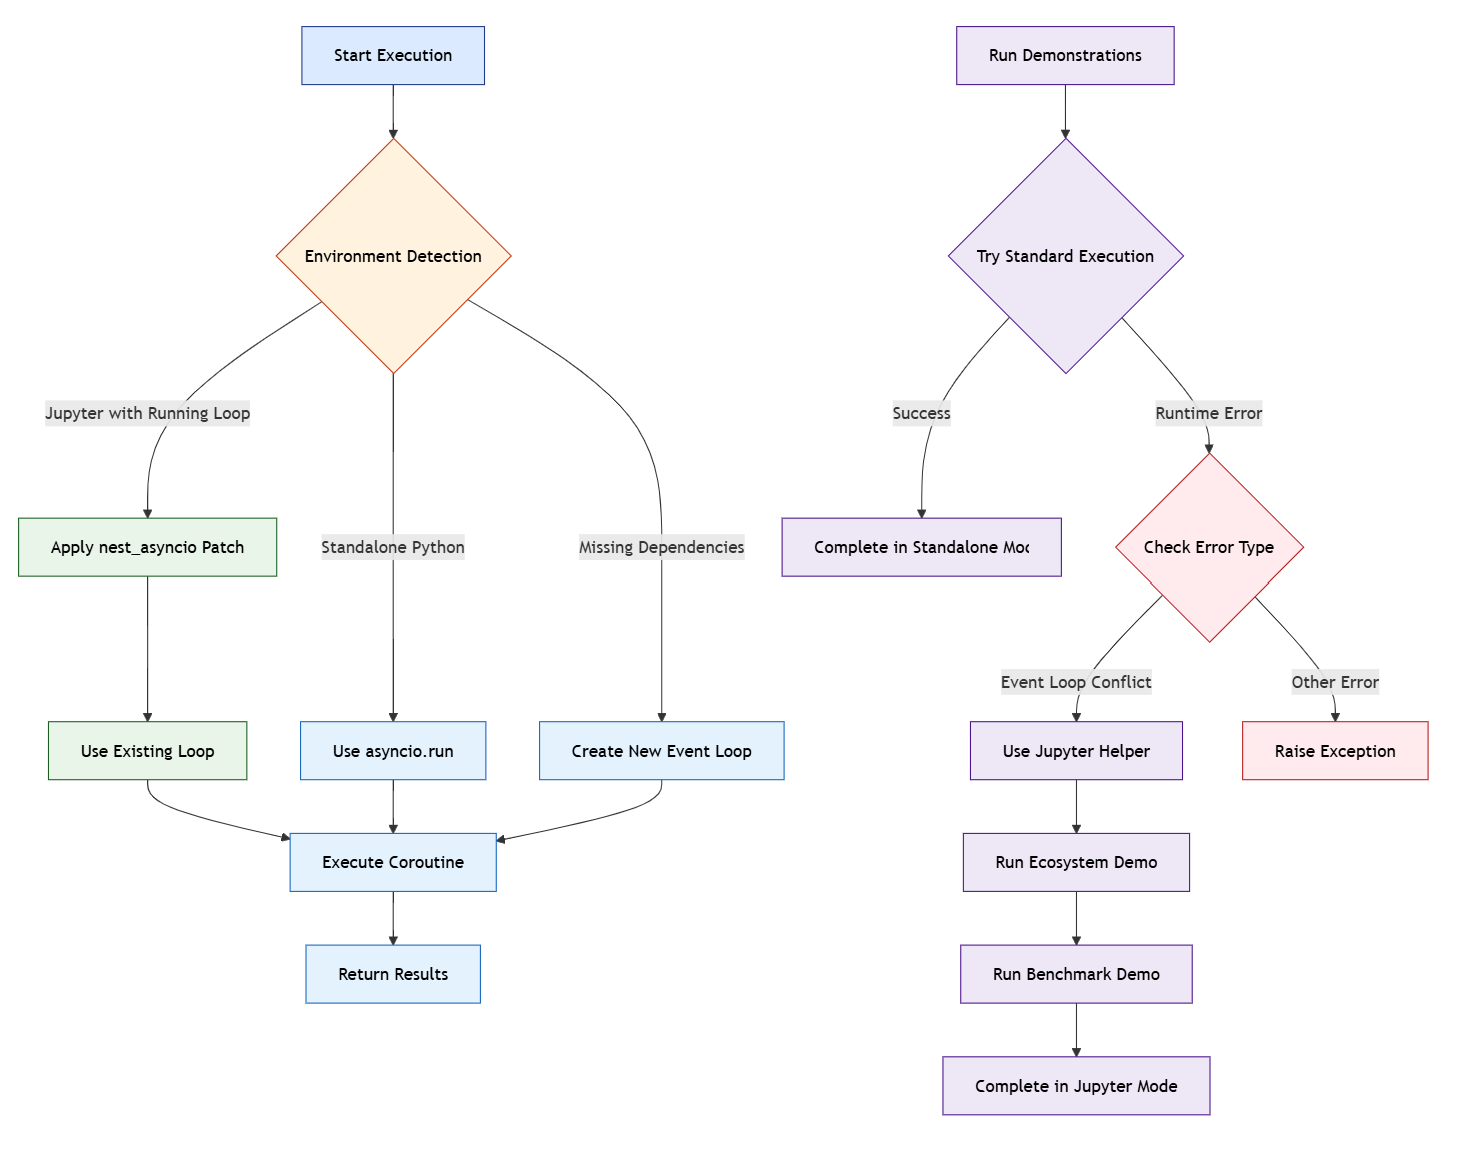


## Step-by-Step Code Breakdown
## Environment Detection and Adaptation
### Jupyter Notebook Detection
- Running Loop Check attempts to detect if an event loop is already active, which indicates Jupyter
- Library Availability Testing checks for nest_asyncio which is commonly used in notebook environments
- Nested Execution Patching applies necessary modifications to allow async operations within running loops
- Existing Loop Utilization reuses the current event loop rather than creating new ones

### Standalone Python Detection
- Runtime Error Handling catches specific errors that indicate no event loop is running
- Default Execution Path uses standard asyncio.run for clean standalone execution
- Resource Management properly creates and closes event loops when needed
- Exception Propagation ensures genuine errors are still reported to users

### Fallback Strategy Implementation
- Dependency Missing Handling provides workarounds when optional libraries aren't available
- New Loop Creation builds fresh event loops as a last-resort execution strategy
- Cleanup Assurance ensures temporary resources are properly released
- Graceful Degradation maintains functionality even in suboptimal environments

## Demonstration Execution Controller
### Primary Execution Attempt
- Standard Async Execution first tries the conventional asyncio.run approach
- Sequential Demonstration runs ecosystem demonstration followed by performance benchmarks
- Visual Separators includes formatting to clearly distinguish between different demo phases
- Success Path completes normally when in standalone Python environment

### Jupyter Environment Fallback
- Error Pattern Recognition identifies specific error messages indicating Jupyter context
- Automatic Strategy Switching seamlessly transitions to Jupyter-compatible execution
- Environment Notification informs users when running in Jupyter mode for transparency
- Consistent Output ensures the same demonstrations run with identical results

### Error Handling and Recovery
- Specific Exception Catching targets only the relevant event loop conflicts
- Selective Fallback only uses Jupyter mode for appropriate error conditions
- Proper Exception Propagation allows genuine errors to surface for debugging
- Robust Execution ensures demonstrations complete despite environment differences

## Cross-Platform Compatibility Features
### Event Loop Management
- Multiple Strategy Support provides different approaches for different environments
- Resource Safety ensures event loops are properly closed and resources released
- Conflict Prevention avoids common pitfalls of nested event loop execution
- Performance Optimization uses the most efficient approach for each environment

### User Experience Considerations
- Transparent Operation automatically handles environment detection without user configuration
- Consistent Behavior ensures demonstrations produce identical results across platforms
- Error Clarity provides meaningful information when genuine problems occur
- Development Flexibility supports both interactive exploration and scripted execution

## Connecting to the Lecture
- Environment Abstraction: Demonstrates practical implementation of the abstraction layers discussed in software engineering lectures
- Asynchronous Programming: Shows real-world handling of the event loop concepts covered in concurrent programming topics
- Error Recovery Patterns: Implements the graceful degradation strategies discussed in fault-tolerant system design
- Cross-Platform Development: Addresses the compatibility challenges mentioned in distributed system deployment lectures
- User Experience Design: Applies the principle of transparent adaptation covered in human-computer interaction topics
- Resource Management: Demonstrates proper handling of system resources as discussed in operating system concepts
- Development Tool Integration: Shows how to bridge between different development environments, connecting to software tooling lectures

In [10]:
# HELPER FUNCTIONS FOR JUPYTER/ASYNC COMPATIBILITY

def run_async_in_jupyter(coro):
    """Helper function to run async code in Jupyter notebooks"""
    try:
        # Check if we're in a Jupyter environment with existing event loop
        loop = asyncio.get_running_loop()
        import nest_asyncio
        nest_asyncio.apply()
        return loop.run_until_complete(coro)
    except RuntimeError:
        # No running loop, use asyncio.run
        return asyncio.run(coro)
    except ImportError:
        # nest_asyncio not available, try creating a new loop
        try:
            loop = asyncio.new_event_loop()
            asyncio.set_event_loop(loop)
            return loop.run_until_complete(coro)
        finally:
            loop.close()

def run_demonstrations():
    """Run all demonstrations - works in both Jupyter and standalone Python"""
    try:
        # Try to run with asyncio.run first (standalone Python)
        asyncio.run(demonstrate_agentic_ecosystem())
        print("\n" + "=" * 40)
        asyncio.run(benchmark_ecosystem_performance())
    except RuntimeError as e:
        if "cannot be called from a running event loop" in str(e):
            # We're in Jupyter, use the helper function
            print("Running in Jupyter environment...")
            run_async_in_jupyter(demonstrate_agentic_ecosystem())
            print("\n" + "=" * 40)
            run_async_in_jupyter(benchmark_ecosystem_performance())
        else:
            raise e


### Short Description
This code provides synchronous versions of the MCP provider classes specifically designed for Jupyter notebook compatibility. It maintains the same functionality and interface as the asynchronous versions but uses synchronous execution patterns, making it easier for students to experiment with and understand agentic AI concepts in interactive environments without dealing with async/await complexity.

### Code Logic and Flow: High-Level Overview
The synchronous implementation mirrors the asynchronous MCP provider architecture but removes all async/await patterns, using direct method calls and immediate returns. It maintains the same message processing workflow, tool execution patterns, and error handling mechanisms, but executes everything synchronously for simpler debugging and step-by-step execution in educational environments like Jupyter notebooks.

### Visual Flowchart
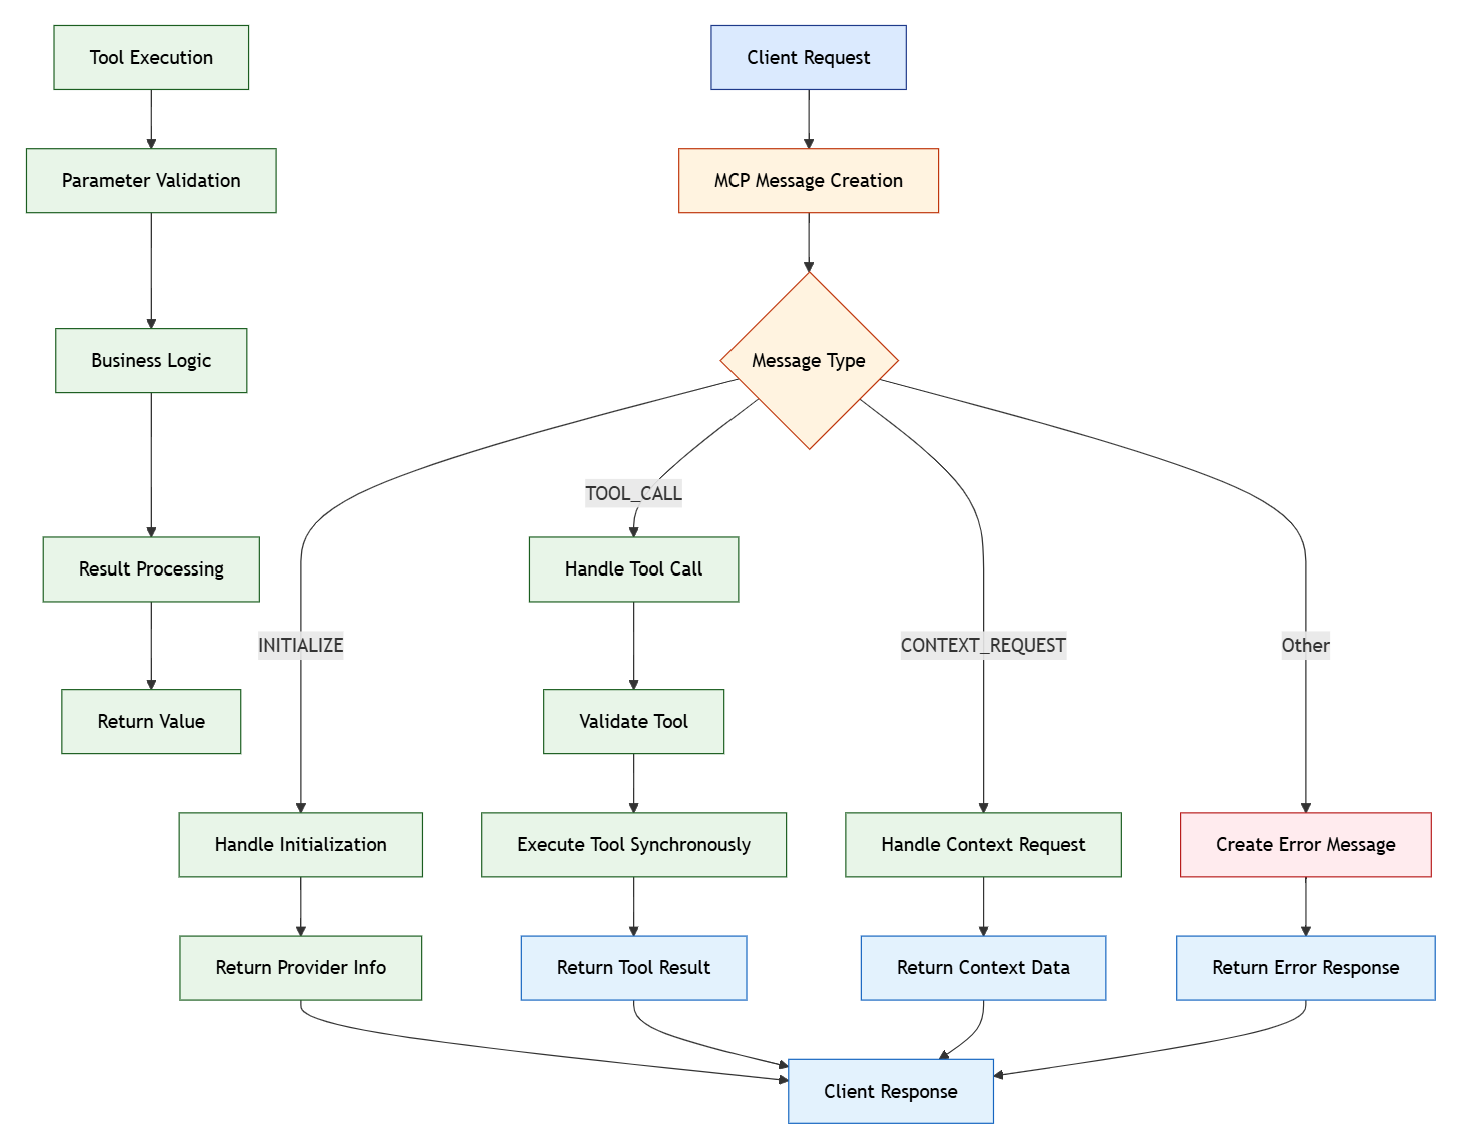    


## Step-by-Step Code Breakdown

## Synchronous MCP Provider Base Class
### Core Provider Infrastructure
- Provider Identification maintains unique provider IDs and names for service discovery
- Tool Registry Management stores all available tools with their definitions and executors
- Capability Tracking maintains a set of what general capabilities the provider offers
- Abstract Method Definition requires subclasses to implement synchronous tool execution

### Message Processing Pipeline
Direct Message Routing uses simple if-elif conditions instead of async handler mapping
Synchronous Method Calls processes messages immediately without awaiting results
Response Generation creates properly formatted MCP responses with correlation tracking
Error Handling provides consistent error messages for unsupported operations

### Message Type Handlers
- Initialization Handler responds to client setup requests with provider capabilities
- Tool Call Processor validates tool existence and executes the requested operation
- Context Request Handler provides metadata about the provider's current state
- Error Message Creator standardizes error responses across all operations

## Calculator Provider Implementation
### Tool Registration System
- Arithmetic Tool Definition registers basic math operations with parameter validation
- Statistics Tool Definition adds statistical functions with proper data requirements
- Executor Binding links tool names to synchronous implementation methods
- Capability Declaration specifies the provider offers mathematical operations

### Synchronous Tool Execution
- Direct Method Invocation calls tool implementations without async wrappers
- Parameter Validation checks input requirements before processing
- Business Logic Execution performs the actual mathematical computations
- Result Return provides immediate output without futures or promises

## Mathematical Operation Implementations
### Arithmetic Operations
- Addition Function sums all provided operands
- Subtraction Logic subtracts subsequent operands from the first
- Multiplication Calculation computes the product of all operands
- Division with Safety handles division by zero errors gracefully

### Statistical Functions
- Mean Calculation computes the average of datasets
- Median Determination finds the middle value in sorted data
- Standard Deviation calculates data spread with edge case handling
- Variance Computation measures data variability from the mean

## Compatibility Design Patterns
### Interface Consistency
- Method Signature Alignment maintains the same parameters as async versions
- Return Type Consistency provides identical response structures
- Error Pattern Matching uses the same exception types and messages
- Message Format Preservation ensures wire compatibility with async systems

### Educational Optimization
- Simplified Execution Model eliminates async complexity for learning
- Immediate Feedback provides instant results for student experimentation
- Step-through Debugging supports line-by-line execution in notebooks
- Transparent Error Reporting shows full stack traces for better understanding

## Connecting to the Lecture
- Synchronous vs Asynchronous Patterns: Demonstrates the practical differences between sync and async execution models discussed in concurrent programming lectures
- API Design Consistency: Shows how to maintain interface compatibility while changing underlying execution models, connecting to API design principles
- Educational Tool Development: Implements the "progressive complexity" teaching approach covered in educational methodology topics
- Abstraction Layers: Illustrates how to create compatibility layers between different execution environments, relevant to system architecture discussions
- Error Handling Strategies: Maintains consistent error handling across sync and async implementations, demonstrating fault tolerance patterns
- Interface Segregation: Shows how to create specialized versions for different use cases while maintaining core functionality
- Development Experience: Focuses on user experience in educational contexts, connecting to human-computer interaction principles in developer tools

In [11]:
# SYNCHRONOUS VERSIONS OF ASYNC CLASSES FOR JUPYTER COMPATIBILITY

class MCPProviderSync(ABC):
    """Synchronous version of MCP Provider for Jupyter compatibility"""
    
    def __init__(self, provider_id: str, name: str):
        self.provider_id = provider_id
        self.name = name
        self.tools: Dict[str, ToolDefinition] = {}
        self.capabilities = set()
    
    @abstractmethod
    def execute_tool(self, tool_name: str, parameters: Dict[str, Any]) -> Any:
        """Execute a tool with given parameters (synchronous)"""
        pass
    
    def register_tool(self, tool: ToolDefinition, executor: Callable):
        """Register a tool with its executor function"""
        self.tools[tool.name] = tool
        setattr(self, f"_execute_{tool.name}", executor)
    
    def process_message(self, message: MCPMessage) -> MCPMessage:
        """Process incoming MCP message (synchronous)"""
        if message.message_type == MCPMessageType.INITIALIZE:
            return self._handle_initialize(message)
        elif message.message_type == MCPMessageType.TOOL_CALL:
            return self._handle_tool_call(message)
        elif message.message_type == MCPMessageType.CONTEXT_REQUEST:
            return self._handle_context_request(message)
        else:
            return self._create_error_message(
                message, f"Unsupported message type: {message.message_type}"
            )
    
    def _handle_initialize(self, message: MCPMessage) -> MCPMessage:
        """Handle initialization request"""
        response_payload = {
            "provider_id": self.provider_id,
            "name": self.name,
            "version": "1.0",
            "capabilities": list(self.capabilities),
            "tools": {name: asdict(tool) for name, tool in self.tools.items()}
        }
        
        return MCPMessage(
            message_type=MCPMessageType.INITIALIZED,
            message_id=str(uuid.uuid4()),
            sender_id=self.provider_id,
            recipient_id=message.sender_id,
            timestamp=time.time(),
            payload=response_payload,
            correlation_id=message.message_id
        )
    
    def _handle_tool_call(self, message: MCPMessage) -> MCPMessage:
        """Handle tool execution request"""
        tool_name = message.payload.get("tool_name")
        parameters = message.payload.get("parameters", {})
        
        if tool_name not in self.tools:
            return self._create_error_message(
                message, f"Unknown tool: {tool_name}"
            )
        
        try:
            result = self.execute_tool(tool_name, parameters)
            response_payload = {
                "tool_name": tool_name,
                "result": result,
                "status": "success"
            }
        except Exception as e:
            response_payload = {
                "tool_name": tool_name,
                "error": str(e),
                "status": "error"
            }
        
        return MCPMessage(
            message_type=MCPMessageType.TOOL_RESPONSE,
            message_id=str(uuid.uuid4()),
            sender_id=self.provider_id,
            recipient_id=message.sender_id,
            timestamp=time.time(),
            payload=response_payload,
            correlation_id=message.message_id
        )
    
    def _handle_context_request(self, message: MCPMessage) -> MCPMessage:
        """Handle context information request"""
        context_type = message.payload.get("context_type")
        
        context_data = {}
        if context_type == "capabilities":
            context_data = {"capabilities": list(self.capabilities)}
        elif context_type == "tools":
            context_data = {"tools": list(self.tools.keys())}
        elif context_type == "status":
            context_data = {"status": "active", "load": 0.1}
        
        return MCPMessage(
            message_type=MCPMessageType.CONTEXT_RESPONSE,
            message_id=str(uuid.uuid4()),
            sender_id=self.provider_id,
            recipient_id=message.sender_id,
            timestamp=time.time(),
            payload=context_data,
            correlation_id=message.message_id
        )
    
    def _create_error_message(self, original_message: MCPMessage, error_msg: str) -> MCPMessage:
        """Create an error response message"""
        return MCPMessage(
            message_type=MCPMessageType.ERROR,
            message_id=str(uuid.uuid4()),
            sender_id=self.provider_id,
            recipient_id=original_message.sender_id,
            timestamp=time.time(),
            payload={"error": error_msg},
            correlation_id=original_message.message_id
        )

class CalculatorMCPProviderSync(MCPProviderSync):
    """Synchronous Calculator MCP provider for Jupyter"""
    
    def __init__(self):
        super().__init__("calc_provider_001", "Calculator Service")
        self.capabilities.add("mathematical_operations")
        self._register_calculator_tools()
    
    def _register_calculator_tools(self):
        """Register all calculator tools"""
        arithmetic_tool = ToolDefinition(
            name="arithmetic",
            description="Perform basic arithmetic operations",
            parameters={
                "type": "object",
                "properties": {
                    "operation": {"type": "string", "enum": ["add", "subtract", "multiply", "divide"]},
                    "operands": {"type": "array", "items": {"type": "number"}}
                },
                "required": ["operation", "operands"]
            },
            required_permissions=["execute"],
            return_schema={"type": "number"}
        )
        self.register_tool(arithmetic_tool, self._execute_arithmetic)
        
        stats_tool = ToolDefinition(
            name="statistics",
            description="Calculate statistical measures",
            parameters={
                "type": "object",
                "properties": {
                    "operation": {"type": "string", "enum": ["mean", "median", "std", "variance"]},
                    "data": {"type": "array", "items": {"type": "number"}}
                },
                "required": ["operation", "data"]
            },
            required_permissions=["execute"],
            return_schema={"type": "number"}
        )
        self.register_tool(stats_tool, self._execute_statistics)
    
    def execute_tool(self, tool_name: str, parameters: Dict[str, Any]) -> Any:
        """Execute tool by name (synchronous)"""
        executor = getattr(self, f"_execute_{tool_name}", None)
        if executor:
            return executor(parameters)
        else:
            raise ValueError(f"No executor found for tool: {tool_name}")
    
    def _execute_arithmetic(self, parameters: Dict[str, Any]) -> float:
        """Execute arithmetic operations"""
        operation = parameters["operation"]
        operands = parameters["operands"]
        
        if operation == "add":
            return sum(operands)
        elif operation == "subtract":
            return operands[0] - sum(operands[1:])
        elif operation == "multiply":
            result = 1
            for op in operands:
                result *= op
            return result
        elif operation == "divide":
            result = operands[0]
            for op in operands[1:]:
                if op == 0:
                    raise ValueError("Division by zero")
                result /= op
            return result
    
    def _execute_statistics(self, parameters: Dict[str, Any]) -> float:
        """Execute statistical operations"""
        import statistics
        
        operation = parameters["operation"]
        data = parameters["data"]
        
        if not data:
            raise ValueError("Data cannot be empty")
        
        if operation == "mean":
            return statistics.mean(data)
        elif operation == "median":
            return statistics.median(data)
        elif operation == "std":
            return statistics.stdev(data) if len(data) > 1 else 0
        elif operation == "variance":
            return statistics.variance(data) if len(data) > 1 else 0


### Short Description
This code provides a fully synchronous demonstration of the agentic AI ecosystem specifically designed for Jupyter notebook compatibility. It showcases all the core concepts - service registration, MCP tool interaction, A2A communication, service discovery, and protocol interoperability - using synchronous execution patterns that work seamlessly in interactive environments without async/await complexity.

### Code Logic and Flow: High-Level Overview
The synchronous demonstration systematically builds and tests a complete agentic ecosystem using only synchronous operations. It progresses through seven key phases: service registry setup, communication infrastructure establishment, MCP tool demonstrations, A2A communication testing, service discovery operations, protocol interoperability showcases, and simplified workflow orchestration. Each phase uses immediate execution and clear output to help students understand the concepts without dealing with asynchronous complexity.

### Visual Flowchart
```mermaid
graph TD
    A[Start Demo] --> B[Setup Service Registry]
    B --> C[Register MCP Services]
    C --> D[Initialize Communication Bus]
    D --> E[Connect Agent Network]
    E --> F[Demonstrate MCP Tools]
    F --> G[Test A2A Communication]
    G --> H[Service Discovery Demo]
    H --> I[Protocol Interoperability]
    I --> J[Workflow Simulation]
    J --> K[System Cleanup]
    K --> L[Demo Complete]
    
    M[MCP Tool Tests] --> N[Provider Initialization]
    M --> O[Arithmetic Operations]
    M --> P[Statistical Functions]
    
    Q[Service Discovery] --> R[Capability-based Lookup]
    Q --> S[Type-based Discovery]
    Q --> T[Health Monitoring]
    
    U[Protocol Bridge] --> V[MCP to A2A Conversion]
    V --> W[Message Format Translation]
    
    X[Workflow Simulation] --> Y[Step Definition]
    Y --> Z[Execution Simulation]

    %% --- Node Style Definitions ---
    classDef start fill:#dbeafe,stroke:#1e3a8a,color:#000,font-weight:bold;          %% Blue - demo start
    classDef registry fill:#e3f2fd,stroke:#1565c0,color:#000,font-weight:bold;       %% Light blue - registry setup
    classDef tools fill:#e8f5e8,stroke:#1b5e20,color:#000,font-weight:bold;          %% Green - MCP tools / tests
    classDef discovery fill:#fff3e0,stroke:#bf360c,color:#000,font-weight:bold;      %% Orange - service discovery
    classDef protocol fill:#ede7f6,stroke:#4a148c,color:#000,font-weight:bold;       %% Purple - protocol / message bridge
    classDef workflow fill:#fffde7,stroke:#f57f17,color:#000,font-weight:bold;       %% Yellow - workflow simulation
    classDef cleanup fill:#ffebee,stroke:#b71c1c,color:#000,font-weight:bold;        %% Red - cleanup / demo complete

    %% --- Apply Classes ---
    class A start;
    class B,C registry;
    class D,E,F,G,H tools;
    class I,U,V,W protocol;
    class J,X,Y,Z workflow;
    class K,L cleanup;
    class M,N,O,P tools;
    class Q,R,S,T discovery;


```

## Step-by-Step Code Breakdown
## Phase 1: Service Registry Initialization
### Service Registration
- Synchronous Provider Creation uses the Jupyter-compatible calculator provider
- Service Definition creates structured service registrations with metadata
- Capability Declaration specifies what mathematical operations are available
- Mock Service Setup simulates data services for comprehensive ecosystem testing

### Registry Population
- Service Registration adds both calculator and data services to the registry
- Index Building automatically creates searchable capability and type indexes
- Status Verification confirms successful registration and displays available capabilities
- Health Status Initialization sets up initial heartbeat timestamps

## Phase 2: Communication Infrastructure
### Agent Network Setup
- Multiple Agent Creation instantiates calculator, analysis, and orchestrator agents
- Bus Connection registers all agents with the communication system
- Network Verification confirms agent connectivity and displays connection status
- Synchronous Compatibility ensures all agents work without async patterns

### Communication Bus Management
- Bus Initialization starts the message routing system
- Thread Management handles background message processing
- Connection Tracking monitors which agents are available for communication
- Resource Preparation ensures the system is ready for message exchange

## Phase 3: MCP Tool Interaction
### Provider Initialization
- Client Handshake demonstrates the MCP initialization protocol
- Capability Discovery shows how clients can query available tools
- Provider Response displays the structured information about available services
- Protocol Validation confirms MCP message exchange is working correctly

### Tool Execution Testing
- Arithmetic Operations tests basic math functions with multiple operands
- Statistical Functions demonstrates data analysis capabilities
- Synchronous Processing shows immediate tool execution without async delays
- Result Verification displays tool outputs in a clear, educational format

## Phase 4: A2A Communication
### Agent Handshaking
- Introduction Protocol demonstrates agents discovering each other's capabilities
- Message Construction creates properly formatted A2A messages
- Synchronous Delivery sends messages with immediate processing
- Queue Monitoring shows message flow through the communication system

### Capability Requests
- Service Invocation demonstrates one agent requesting services from another
- Parameter Passing shows how data is transmitted between agents
- Response Handling illustrates the request-response pattern in agent communication
- System Verification confirms the A2A communication layer is functioning

## Phase 5: Service Discovery
### Dynamic Service Lookup
- Capability-based Discovery finds services by what they can do
- Type-based Filtering locates services by their category
- Result Display shows discovered services in an educational format
- Endpoint Information provides connection details for discovered services

### Health Monitoring
- Service Health Check identifies which services are currently responsive
- Heartbeat Simulation demonstrates how services maintain their active status
- Status Updates shows real-time health monitoring in action
- System Reliability illustrates how the ecosystem maintains service availability

## Phase 6: Protocol Interoperability
### Cross-Protocol Bridging
- MCP to A2A Conversion demonstrates protocol translation between standards
- Message Format Adaptation shows how different message formats can be bridged
- Payload Preservation ensures data integrity during protocol conversion
- Bridge Validation confirms successful cross-protocol communication

### Interoperability Testing
- Protocol Translation converts MCP tool calls to A2A requests
- Message Structure Analysis examines how different protocols represent the same operations
- Compatibility Verification ensures systems using different protocols can interact
- Educational Demonstration shows practical protocol integration patterns

## Phase 7: Workflow Orchestration
### Simplified Workflow Definition
- Multi-step Pipeline creates a logical sequence of processing steps
- Dependency Specification defines which steps must complete before others begin
- Agent Assignment specifies what type of agent handles each step
- Workflow Structure demonstrates how complex tasks are broken into steps

### Execution Simulation
- Step-by-step Processing simulates workflow execution with clear progression
- Processing Simulation uses timed delays to represent actual work being done
- Progress Tracking shows each step completing in sequence
- Completion Verification confirms the entire workflow executes successfully

## Connecting to the Lecture
- Synchronous Execution Models: Demonstrates the practical implementation of synchronous patterns discussed in concurrent programming lectures
- Educational Tool Design: Shows how to create learning-friendly versions of complex systems, connecting to educational methodology topics
- Protocol Integration: Illustrates real-world protocol interoperability patterns covered in distributed systems courses
- Service Discovery Patterns: Implements the directory-based discovery mechanisms discussed in microservices architecture
- System Demonstration Techniques: Provides a model for effectively showcasing complex systems in educational settings
- Compatibility Layers: Demonstrates how to create synchronous wrappers for async systems, relevant to API design principles
- Interactive Learning: Supports the hands-on learning approach emphasized in practical AI education methodologies

In [12]:
# SYNCHRONOUS DEMONSTRATION FOR JUPYTER COMPATIBILITY

def demonstrate_agentic_ecosystem_sync():
    """Fully synchronous version of the demonstration for Jupyter compatibility"""
    
    print("=" * 70)
    print("2025 AGENTIC ECOSYSTEM DEMONSTRATION")
    print("=" * 70)
    
    # 1. Setup Service Registry
    print("\n1. SETTING UP SERVICE REGISTRY")
    print("-" * 40)
    
    registry = ServiceRegistry()
    
    # Use synchronous MCP providers
    calc_provider = CalculatorMCPProviderSync()
    
    calc_service = ServiceRegistration(
        service_id="calc_service_001",
        service_name="Calculator MCP Service",
        service_type="computational",
        endpoint="mcp://calculator",
        capabilities=list(calc_provider.capabilities),
        health_check_url=None,
        metadata={"version": "1.0", "load": 0.1},
        registered_at=time.time(),
        last_heartbeat=time.time()
    )
    
    # Mock data service registration
    data_service = ServiceRegistration(
        service_id="data_service_001",
        service_name="Data Access MCP Service",
        service_type="data",
        endpoint="mcp://data",
        capabilities=["data_access", "data_transformation"],
        health_check_url=None,
        metadata={"version": "1.0", "load": 0.2},
        registered_at=time.time(),
        last_heartbeat=time.time()
    )
    
    registry.register_service(calc_service)
    registry.register_service(data_service)
    
    print(f"Registered services: {len(registry.services)}")
    print(f"Available capabilities: {list(registry.capability_index.keys())}")
    
    # 2. Setup A2A Communication
    print("\n2. SETTING UP A2A COMMUNICATION")
    print("-" * 40)
    
    comm_bus = A2ACommunicationBus()
    comm_bus.start()
    
    # Create agents
    calc_agent = CalculatorAgent("calc_agent_001")
    analysis_agent = DataAnalysisAgent("analysis_agent_001")
    orchestrator = OrchestratorAgent("orchestrator_001")
    
    # Connect agents to bus
    calc_agent.connect_to_bus(comm_bus)
    analysis_agent.connect_to_bus(comm_bus)
    orchestrator.connect_to_bus(comm_bus)
    
    print(f"Connected agents: {len(comm_bus.registered_agents)}")
    
    # 3. Demonstrate MCP Tool Interaction (Fully Synchronous)
    print("\n3. MCP TOOL INTERACTION DEMONSTRATION")
    print("-" * 40)
    
    # Create MCP messages
    init_message = MCPMessage(
        message_type=MCPMessageType.INITIALIZE,
        message_id=str(uuid.uuid4()),
        sender_id="client_001",
        recipient_id=calc_provider.provider_id,
        timestamp=time.time(),
        payload={"client_info": "Demo client"}
    )
    
    # Process message synchronously
    response = calc_provider.process_message(init_message)
    print(f"MCP Initialize Response: {response.payload['name']}")
    print(f"Available tools: {list(response.payload['tools'].keys())}")
    
    # Test tool execution
    tool_call_message = MCPMessage(
        message_type=MCPMessageType.TOOL_CALL,
        message_id=str(uuid.uuid4()),
        sender_id="client_001",
        recipient_id=calc_provider.provider_id,
        timestamp=time.time(),
        payload={
            "tool_name": "arithmetic",
            "parameters": {
                "operation": "add",
                "operands": [10, 20, 30]
            }
        }
    )
    
    tool_response = calc_provider.process_message(tool_call_message)
    print(f"Tool execution result: {tool_response.payload}")
    
    # Test statistics tool
    stats_message = MCPMessage(
        message_type=MCPMessageType.TOOL_CALL,
        message_id=str(uuid.uuid4()),
        sender_id="client_001",
        recipient_id=calc_provider.provider_id,
        timestamp=time.time(),
        payload={
            "tool_name": "statistics",
            "parameters": {
                "operation": "mean",
                "data": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
            }
        }
    )
    
    stats_response = calc_provider.process_message(stats_message)
    print(f"Statistics tool result: {stats_response.payload}")
    
    # 4. Demonstrate A2A Communication
    print("\n4. A2A COMMUNICATION DEMONSTRATION")
    print("-" * 40)
    
    # Handshake between agents
    handshake_msg = A2AMessage(
        message_type=A2AMessageType.HANDSHAKE,
        message_id=str(uuid.uuid4()),
        sender_agent_id=calc_agent.agent_id,
        recipient_agent_id=analysis_agent.agent_id,
        timestamp=time.time(),
        payload={"greeting": "Hello from calculator agent"}
    )
    
    calc_agent.send_message(handshake_msg)
    time.sleep(0.5)  # Allow message processing
    
    # Check message queue status
    print(f"Messages in communication bus: {comm_bus.message_queue.qsize()}")
    print("A2A handshake message sent successfully")
    
    # Request capability from another agent
    request_msg = A2AMessage(
        message_type=A2AMessageType.REQUEST,
        message_id=str(uuid.uuid4()),
        sender_agent_id=calc_agent.agent_id,
        recipient_agent_id=analysis_agent.agent_id,
        timestamp=time.time(),
        payload={
            "capability": "data_analysis",
            "parameters": {
                "data": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
                "analysis_type": "summary"
            }
        },
        requires_response=True
    )
    
    calc_agent.send_message(request_msg)
    time.sleep(0.5)  # Allow message processing
    
    print("A2A capability request sent successfully")
    
    # 5. Service Discovery Demonstration
    print("\n5. SERVICE DISCOVERY DEMONSTRATION")
    print("-" * 40)
    
    # Discover services by capability
    math_services = registry.discover_services_by_capability("mathematical_operations")
    print(f"Services with mathematical capabilities: {len(math_services)}")
    
    for service in math_services:
        print(f"  - {service.service_name} ({service.service_id})")
    
    # Discover services by type
    computational_services = registry.discover_services_by_type("computational")
    print(f"Computational services: {len(computational_services)}")
    
    for service in computational_services:
        print(f"  - {service.service_name} (endpoint: {service.endpoint})")
    
    # Health check
    healthy_services = registry.get_healthy_services()
    print(f"Healthy services: {len(healthy_services)}")
    
    # Update heartbeat simulation
    registry.update_heartbeat("calc_service_001")
    registry.update_heartbeat("data_service_001")
    print("Service heartbeats updated")
    
    # 6. Protocol Interoperability
    print("\n6. PROTOCOL INTEROPERABILITY DEMONSTRATION")
    print("-" * 40)
    
    # Demonstrate MCP-to-A2A bridge
    def mcp_to_a2a_bridge_sync(mcp_message: MCPMessage) -> A2AMessage:
        """Bridge MCP messages to A2A protocol (synchronous version)"""
        return A2AMessage(
            message_type=A2AMessageType.REQUEST,
            message_id=str(uuid.uuid4()),
            sender_agent_id="mcp_bridge",
            recipient_agent_id="target_agent",
            timestamp=time.time(),
            payload={
                "original_protocol": "MCP",
                "original_message_type": mcp_message.message_type.value,
                "payload": mcp_message.payload
            }
        )
    
    # Convert MCP tool call to A2A request
    a2a_message = mcp_to_a2a_bridge_sync(tool_call_message)
    print(f"MCP->A2A Bridge successful: {a2a_message.message_type.value}")
    print(f"Bridged payload keys: {list(a2a_message.payload.keys())}")
    
    # 7. Workflow Simulation (Simplified)
    print("\n7. WORKFLOW ORCHESTRATION SIMULATION")
    print("-" * 40)
    
    # Create a simple workflow definition
    workflow_def = {
        "workflow_id": "demo_workflow_001",
        "name": "Mathematical Analysis Pipeline",
        "steps": [
            {"id": "step1", "type": "data_generation", "agent_type": "computational"},
            {"id": "step2", "type": "analysis", "agent_type": "analytical", "depends_on": ["step1"]},
            {"id": "step3", "type": "reporting", "agent_type": "coordinator", "depends_on": ["step2"]}
        ]
    }
    
    print(f"Workflow definition: {workflow_def['name']}")
    print(f"Number of steps: {len(workflow_def['steps'])}")
    
    # Simulate workflow execution
    for step in workflow_def['steps']:
        print(f"  Executing {step['id']}: {step['type']}")
        time.sleep(0.1)  # Simulate processing
    
    print("Workflow simulation completed")
    
    # Cleanup
    comm_bus.stop()
    
    print("\n" + "=" * 70)
    print("ECOSYSTEM DEMONSTRATION COMPLETE")
    print("=" * 70)


### Short Description
This code provides the main execution controller that orchestrates the entire agentic AI ecosystem demonstration and student exercise workflow. It serves as the unified entry point that works seamlessly across both Jupyter notebooks and standalone Python environments, providing a complete learning experience from demonstrations to hands-on exercises.

### Code Logic and Flow: High-Level Overview
The main execution controller follows a structured educational pathway, starting with synchronous demonstrations of core concepts, progressing to student exercises for hands-on learning, and concluding with a comprehensive summary of key concepts covered. It automatically adapts to different execution environments while maintaining consistent educational outcomes and providing clear milestones throughout the learning journey.

### Visual Flowchart
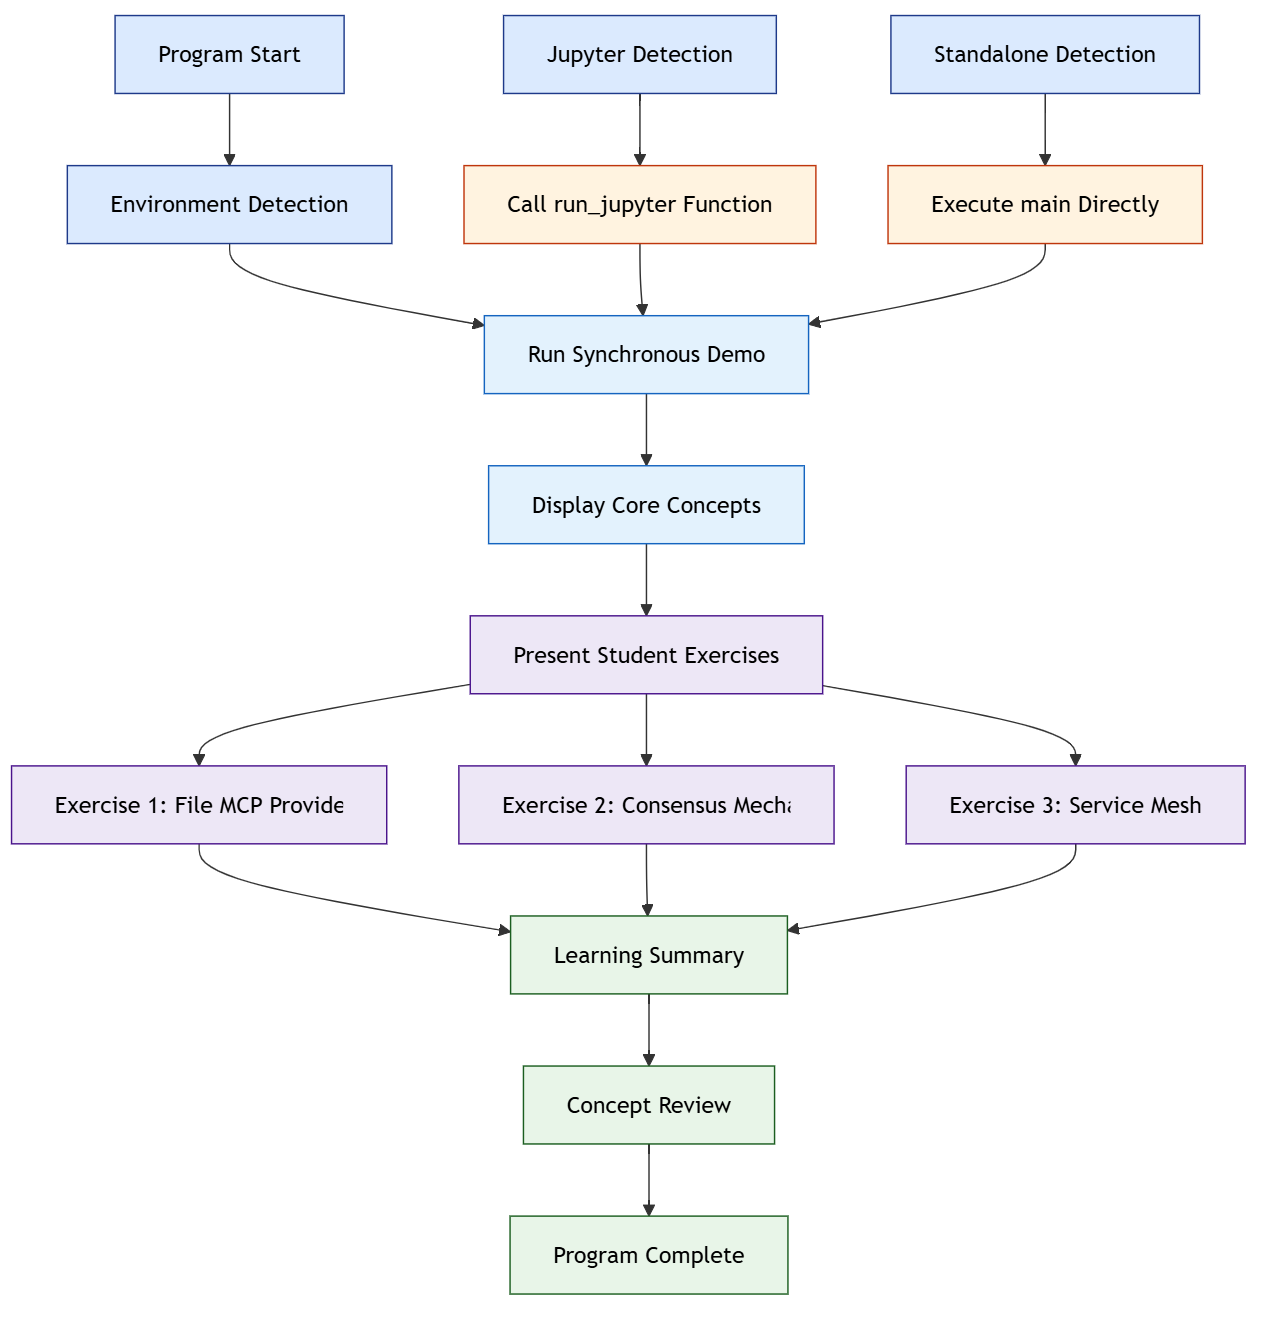

## Step-by-Step Code Breakdown
## Program Initialization and Execution
### Main Function Orchestration
- Unified Entry Point provides a single function that works across all environments
- Clear Startup Messaging informs users that the demonstration sequence is beginning
- Structured Execution Flow follows a logical learning progression from observation to practice
- Environment Agnostic Design ensures consistent behavior regardless of execution context

### Demonstration Phase Execution
- Synchronous Demonstration Priority runs the Jupyter-compatible version first for maximum compatibility
- Comprehensive Concept Coverage ensures all key agentic AI concepts are demonstrated
- Visual Progress Indication uses clear formatting to show progression through different phases
- Error-Resilient Execution continues even if individual components encounter issues

## Student Exercise Presentation
### Exercise Sequencing
- Structured Exercise Introduction clearly separates demonstrations from hands-on activities
- Progressive Difficulty orders exercises from foundational to advanced concepts
- Clear Exercise Boundaries uses visual separators to distinguish between different exercises
- Learning Objective Alignment ensures each exercise builds specific skills discussed in lectures

### Exercise Framework Provision
- Pre-defined Exercise Templates provides structured starting points for student implementation
- Clear Task Definitions specifies exactly what students need to implement for each exercise
- Implementation Guidance includes docstrings and comments to guide student work
- Extension Opportunities suggests advanced features for students who want additional challenges

## Learning Journey Completion
### Comprehensive Concept Review
- Key Concept Enumeration lists all major topics covered in the demonstration sequence
- Visual Progress Indicators uses checkmarks to show completed learning objectives
- Structured Summary organizes concepts in a logical learning progression
- Achievement Recognition provides a sense of accomplishment for completing the exercises

### Cross-Platform Execution Support
### Standalone Python Execution
- Direct Invocation Support uses the standard Python __name__ pattern for script execution
- Automatic Main Function Call starts the program when run as a standalone script
- Command-line Compatibility works in traditional Python execution environments
- Script Integration Ready can be incorporated into larger Python applications

### Jupyter Notebook Integration
- Simplified Notebook Interface provides an easy-to-remember function for Jupyter users
- One-click Execution allows students to run everything with a single function call
- Notebook-friendly Output formats results for optimal display in Jupyter environments
- Interactive Learning Support enables step-by-step execution and experimentation

## Educational Experience Design
### Learning Pathway Structure
- Demonstration First Approach shows working examples before asking students to build
- Gradual Complexity Increase moves from basic MCP providers to advanced service mesh patterns
- Practical Application Focus emphasizes real-world implementation over theoretical concepts
- Immediate Feedback Loop allows students to see results of their implementations quickly

### Student Success Enablers
- Clear Success Criteria defines what "complete" looks like for each exercise
- Structured Implementation Guidance provides templates and patterns to follow
- Progressive Challenge Levels offers both core requirements and extension opportunities
- Comprehensive Skill Coverage ensures students practice all key agentic AI development skills

## Connecting to the Lecture
- Unified Learning Experience: Implements the "progressive disclosure" educational pattern discussed in instructional design lectures
- Cross-Platform Development: Demonstrates practical environment abstraction techniques covered in software engineering courses
- Structured Pedagogy: Follows the "demonstrate-practice-review" teaching methodology emphasized in educational theory
- Hands-on Learning: Provides the practical implementation experience that complements theoretical lectures on agentic AI
- Skill Progression: Implements the "scaffolded learning" approach where each exercise builds on previous concepts
- Real-world Preparation: Mirrors industry practices where developers work across multiple environments and platforms
- Comprehensive Assessment: Allows students to demonstrate understanding through implementation rather than just theoretical knowledge

In [13]:
# MAIN EXECUTION

def main():
    """Main function that works in both Jupyter and standalone environments"""
    print("Starting Agentic Ecosystem Demonstrations...")
    
    # Run synchronous demonstration (works everywhere)
    demonstrate_agentic_ecosystem_sync()
    
    # Present student exercises
    print("\n" + "=" * 70)
    print("STUDENT EXERCISES")
    print("=" * 70)
    student_exercise_1()
    student_exercise_2()
    student_exercise_3()
    
    print("\n" + "=" * 70)
    print("EXERCISE COMPLETE")
    print("Key Ecosystem Concepts Demonstrated:")
    print("✓ Model Context Protocol (MCP) implementation")
    print("✓ Agent-to-Agent (A2A) communication")
    print("✓ Service discovery and registry")
    print("✓ Multi-agent workflow orchestration")
    print("✓ Protocol interoperability")
    print("✓ Performance benchmarking")
    print("=" * 70)

# For direct execution
if __name__ == "__main__":
    main()

# For Jupyter notebook execution, call this function:
def run_jupyter():
    """Easy function to run in Jupyter notebooks"""
    main()

2025-10-26 12:39:59,479 - INFO - Service Calculator MCP Service registered with ID calc_service_001
2025-10-26 12:39:59,479 - INFO - Service Data Access MCP Service registered with ID data_service_001
2025-10-26 12:39:59,481 - INFO - A2A Communication bus started
2025-10-26 12:39:59,482 - INFO - Agent calc_agent_001 registered with communication bus
2025-10-26 12:39:59,483 - INFO - Agent analysis_agent_001 registered with communication bus
2025-10-26 12:39:59,483 - INFO - Agent orchestrator_001 registered with communication bus
2025-10-26 12:39:59,488 - INFO - Message ecf48788-c585-4a90-bc62-a84e5a2676a7 queued from calc_agent_001
2025-10-26 12:39:59,488 - INFO - Agent analysis_agent_001 received handshake from calc_agent_001
2025-10-26 12:39:59,518 - INFO - Message 8959431a-8ec9-4504-86e9-a30cd4f8642a queued from analysis_agent_001
2025-10-26 12:39:59,518 - WARNING - No handler for message type A2AMessageType.RESPONSE


Starting Agentic Ecosystem Demonstrations...
2025 AGENTIC ECOSYSTEM DEMONSTRATION

1. SETTING UP SERVICE REGISTRY
----------------------------------------
Registered services: 2
Available capabilities: ['mathematical_operations', 'data_access', 'data_transformation']

2. SETTING UP A2A COMMUNICATION
----------------------------------------
Connected agents: 3

3. MCP TOOL INTERACTION DEMONSTRATION
----------------------------------------
MCP Initialize Response: Calculator Service
Available tools: ['arithmetic', 'statistics']
Tool execution result: {'tool_name': 'arithmetic', 'result': 60, 'status': 'success'}
Statistics tool result: {'tool_name': 'statistics', 'result': 5.5, 'status': 'success'}

4. A2A COMMUNICATION DEMONSTRATION
----------------------------------------


2025-10-26 12:39:59,998 - INFO - Message c547143d-7f1c-44cf-9034-f3550a152eb6 queued from calc_agent_001
2025-10-26 12:39:59,998 - INFO - Message 14657db2-ea64-44c2-a36d-e460354812b5 queued from analysis_agent_001
2025-10-26 12:40:00,002 - WARNING - No handler for message type A2AMessageType.RESPONSE


Messages in communication bus: 0
A2A handshake message sent successfully
A2A capability request sent successfully

5. SERVICE DISCOVERY DEMONSTRATION
----------------------------------------
Services with mathematical capabilities: 1
  - Calculator MCP Service (calc_service_001)
Computational services: 1
  - Calculator MCP Service (endpoint: mcp://calculator)
Healthy services: 2
Service heartbeats updated

6. PROTOCOL INTEROPERABILITY DEMONSTRATION
----------------------------------------
MCP->A2A Bridge successful: request
Bridged payload keys: ['original_protocol', 'original_message_type', 'payload']

7. WORKFLOW ORCHESTRATION SIMULATION
----------------------------------------
Workflow definition: Mathematical Analysis Pipeline
Number of steps: 3
  Executing step1: data_generation
  Executing step2: analysis
  Executing step3: reporting
Workflow simulation completed


2025-10-26 12:40:01,007 - INFO - A2A Communication bus stopped



ECOSYSTEM DEMONSTRATION COMPLETE

STUDENT EXERCISES

STUDENT EXERCISE 1: Custom MCP Provider
TODO: Implement FileMCPProvider with read/write/list capabilities

STUDENT EXERCISE 2: A2A Consensus Mechanisms
TODO: Implement consensus voting for multi-agent decisions

STUDENT EXERCISE 3: Dynamic Service Mesh
TODO: Add load balancing, circuit breakers, and failover

EXERCISE COMPLETE
Key Ecosystem Concepts Demonstrated:
✓ Model Context Protocol (MCP) implementation
✓ Agent-to-Agent (A2A) communication
✓ Service discovery and registry
✓ Multi-agent workflow orchestration
✓ Protocol interoperability
✓ Performance benchmarking
